# Разработка модели поведенческого скоринга для прогнозирования просрочки клиентов банка «Ва-банк»

Автор: Мельников Артём Владимирович

Дата: 24.05.2026

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

# Цели и задачи проекта

В рамках проекта необходимо разработать модель поведенческого скоринга для банка «Ва-банк».

Цель исследования - предсказать вероятность того, что у клиента банка возникнет просрочка по кредиту длительностью 90 дней и более в течение ближайших 12 месяцев.

Для решения задачи будут использоваться данные о клиентах банка, их транзакционной активности, кредитной нагрузке, ипотеке, кредитном рейтинге и макроэкономических показателях.

Основные задачи проекта:

- изучить и проанализировать предоставленные данные;
- собрать единую таблицу наблюдений для моделирования;
- сформировать целевую переменную с учетом временной структуры данных;
- исследовать баланс классов;
- обучить и сравнить модели классификации;
- оценить качество моделей с помощью технических и бизнес-метрик;
- подобрать оптимальный порог принятия решения;
- проанализировать устойчивость и интерпретируемость итоговой модели.

# Описание данных

Для выполнения проекта предоставлено несколько таблиц с данными о клиентах банка и их финансовом поведении.

**Таблица `ds_15_loan_payment_credit.csv`**
Содержит информацию о просрочках по кредитам.

Основные признаки:
- `ID` - идентификатор клиента;
- `дата_начала_периода` - дата начала просрочки;
- `просрочка_дней` - длительность просрочки в днях.

**Таблица `ds_15_transactions.csv`**
Содержит помесячные траты клиентов по MCC-кодам.

Основные признаки:
- `ID` - идентификатор клиента;
- `date` - дата наблюдения;
- MCC-категории расходов клиентов.

**Таблица `ds_15_client_description.csv`**
Содержит информацию о клиентах на момент регистрации в банке.

Основные признаки:
- `ID` - идентификатор клиента;
- `возраст`;
- `семейное_положение`;
- `наличие_иждивенцев`;
- `дата_регистрации`.

**Таблица `ds_15_credit_description.csv`**
Содержит описание кредита клиента.

Основные признаки:
- `ID` - идентификатор клиента;
- `доход`;
- `сумма_кредита`.

**Таблица `ds_15_mortgage_presence.csv`**
Содержит данные о наличии ипотеки.

Основные признаки:
- `ID` - идентификатор клиента;
- `дата_открытия`;
- `наличие_ипотеки`.

**Таблица `ds_15_credit_rating.csv`**
Содержит информацию о кредитном рейтинге клиентов.

Основные признаки:
- `ID` - идентификатор клиента;
- `date`;
- `кредитный_рейтинг`.

**Таблица `ds_15_macro_data.csv`**
Содержит макроэкономические показатели.

Основные признаки:
- `date`;
- `учетная_ставка`;
- `уровень_безработицы`;
- `инфляция`.

**Таблица `ds_15_cohort_grid.csv`**
Содержит даты проведения поведенческого скоринга.

Основные признаки:
- `ID` - идентификатор клиента;
- `score_date` - дата проведения скоринга.

# План работы

Работа над проектом будет состоять из нескольких этапов:

1. Подготовка рабочего пространства и загрузка библиотек.
2. Загрузка и первичное изучение данных.
3. Исследовательский анализ таблиц.
4. Формирование целевой переменной.
5. Объединение данных в единую таблицу наблюдений.
6. Создание дополнительных признаков.
7. Анализ итоговой таблицы и исследование дисбаланса классов.
8. Подготовка выборок для моделирования.
9. Обучение и сравнение моделей классификации.
10. Подбор гиперпараметров и калибровка лучшей модели.
11. Подбор оптимального порога классификации.
12. Анализ качества модели и матриц ошибок.
13. Анализ важности признаков.
14. Формулировка итоговых выводов и рекомендаций.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


В рамках проекта решается задача бинарной классификации с временной структурой данных.

Целевая переменная:
- `1` - у клиента возникнет просрочка длительностью 90 дней и более в течение следующих 12 месяцев;
- `0` - такой просрочки не возникнет.

Объект наблюдения - клиент банка в конкретный месяц проведения скоринга.

Для решения задачи планируется:

- объединить данные из нескольких таблиц в единую таблицу наблюдений;
- сформировать целевую переменную с учетом временного горизонта прогнозирования;
- использовать только ту информацию, которая была доступна на дату скоринга, чтобы избежать утечки данных;
- выполнить анализ и обработку категориальных и числовых признаков;
- исследовать дисбаланс классов и протестировать методы балансировки данных;
- разделить данные на обучающую, калибровочную и тестовую выборки с учетом временной структуры;
- использовать кросс-валидацию с применением `GroupTimeSeriesSplit`.

В качестве моделей машинного обучения планируется использовать:

- Logistic Regression;
- Random Forest Classifier.

Также планируется сравнить модели:
- без балансировки классов;
- с применением методов балансировки классов.

Для оценки качества моделей будут использоваться:
- ROC-AUC или accuracy;
- approval rate;
- default rate;
- missed defaults rate.

После выбора лучшей модели будет выполнена:
- настройка гиперпараметров;
- калибровка вероятностей;
- подбор оптимального порога классификации;
- анализ важности признаков.

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

Для выполнения проекта подготовим рабочее окружение: установим необходимые библиотеки, импортируем инструменты для анализа данных, визуализации, построения моделей и оценки качества.

Также заранее настроим отображение таблиц и графиков, чтобы результаты анализа было удобнее читать.

In [1]:
# Установка совместимых версий библиотек
!pip install -q \
numpy==1.26.4 \
pandas==2.2.2 \
scikit-learn==1.6.1 \
matplotlib==3.8.4 \
seaborn==0.13.2 \
joblib \
optuna \
mlxtend \
imbalanced-learn \
phik

In [2]:
# Подключим библиотеки через try|except, чтобы ничего не упало

try:

    # Базовые библиотеки

    import os
    import math
    import warnings

    import numpy as np
    import pandas as pd
    import joblib

    # Визуализация

    import matplotlib.pyplot as plt
    import seaborn as sns

    # Дополнительные библиотеки

    import phik
    import optuna

    from scipy.special import expit

    # Метрики

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
        brier_score_loss,
        make_scorer
    )

    # Разделение данных и кросс-валидация

    from sklearn.model_selection import (
        train_test_split,
        cross_validate,
        cross_val_score,
        StratifiedKFold
    )

    # Предобработка данных

    from sklearn.preprocessing import (
        StandardScaler,
        OneHotEncoder
    )

    from sklearn.compose import ColumnTransformer

    from sklearn.pipeline import Pipeline

    from sklearn.impute import SimpleImputer

    # Модели машинного обучения

    from sklearn.dummy import DummyClassifier

    from sklearn.linear_model import LogisticRegression

    from sklearn.ensemble import RandomForestClassifier

    # Калибровка вероятностей

    from sklearn.calibration import (
        calibration_curve,
        CalibratedClassifierCV
    )

    from sklearn.frozen import FrozenEstimator

    # Балансировка классов

    from imblearn.pipeline import Pipeline as ImbPipeline

    from imblearn.over_sampling import SMOTE

    from imblearn.under_sampling import RandomUnderSampler

    # Работа с временными фолдами

    from mlxtend.evaluate.time_series import (
        GroupTimeSeriesSplit,
        print_split_info
    )

    print('Все библиотеки успешно импортированы')

except ImportError as error:

    print(f'Ошибка импорта: {error}')

Все библиотеки успешно импортированы


In [3]:
# Сохраняем список установленных библиотек
!pip freeze > requirements.txt

**Базовые настройки проекта**

In [4]:
# Константы проекта
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
N_JOBS = -1 # задействуем все ядра для вычислений

# Настройки отображения pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', None)

# Формат отображения чисел
pd.set_option('display.float_format', lambda value: f'{value:.4f}')

# Настройки стиля графиков
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')

# тема
sns.set_theme(
    style='whitegrid',
    palette='muted'
)

sns.set_context('notebook')

# Параметры отображения matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Отображение графиков внутри ноутбука
%matplotlib inline

# Отключение предупреждений
#warnings.filterwarnings('ignore')
#optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore', category=FutureWarning)

print('Настройки отображения успешно применены')

Настройки отображения успешно применены


In [5]:
# Вспомогательная функция для подписей над столбцами на графиках

def add_bar_labels(ax, fmt="{:.3f}", offset=0.0):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height + offset),
            ha="center",
            va="bottom"
        )

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

Загрузим все таблицы, которые понадобятся для проекта. После загрузки посмотрим на первые строки, типы данных, количество клиентов, дубликаты и диапазон дат.

На этом этапе данные пока не меняем - только знакомимся с ними и проверяем, что они загрузились корректно.

In [6]:
# Функция для загрузки датасетов

def read_data(file_name):
    """
    Загружает датасет локально или из облачного хранилища.
    """
    
    local_path = f'/datasets/{file_name}'
    cloud_path = f'https://code.s3.yandex.net/datasets/{file_name}'
    
    try:
        data = pd.read_csv(local_path)
        print(f'Файл {file_name} успешно загружен локально')
        return data
    
    except FileNotFoundError:
        
        try:
            data = pd.read_csv(cloud_path)
            print(f'Файл {file_name} успешно загружен из облака')
            return data
        
        except Exception as error:
            print(f'Ошибка при загрузке файла {file_name}: {error}')
            return None

In [7]:
# Загружаем таблицы проекта

loan_payment = read_data('ds_15_loan_payment_credit.csv')

transactions = read_data('ds_15_transactions.csv')

client_description = read_data('ds_15_client_description.csv')

credit_description = read_data('ds_15_credit_description.csv')

mortgage_presence = read_data('ds_15_mortgage_presence.csv')

credit_rating = read_data('ds_15_credit_rating.csv')

macro_data = read_data('ds_15_macro_data.csv')

cohort_grid = read_data('ds_15_cohort_grid.csv')

Файл ds_15_loan_payment_credit.csv успешно загружен локально
Файл ds_15_transactions.csv успешно загружен локально
Файл ds_15_client_description.csv успешно загружен локально
Файл ds_15_credit_description.csv успешно загружен локально
Файл ds_15_mortgage_presence.csv успешно загружен локально
Файл ds_15_credit_rating.csv успешно загружен локально
Файл ds_15_macro_data.csv успешно загружен локально
Файл ds_15_cohort_grid.csv успешно загружен локально


In [8]:
# Функция для первичного анализа таблиц

def inspect_table(dataframe, table_name, date_column=None, id_column='ID'):

    print(f'\nТаблица: {table_name}')
    print('=' * 80)

    display(dataframe.head())

    print('\nОбщая информация:')
    dataframe.info()

    print('\nРазмер таблицы:')
    print(f'Количество строк: {dataframe.shape[0]}')
    print(f'Количество столбцов: {dataframe.shape[1]}')

    print('\nКоличество пропусков:')
    display(
        dataframe.isna()
        .sum()
        .to_frame(name='missing_values')
    )

    print('\nКоличество дубликатов:')
    print(f'Полных дубликатов: {dataframe.duplicated().sum()}')

    if id_column and id_column in dataframe.columns:

        print(f'Уникальных клиентов: {dataframe[id_column].nunique()}')

        print(f'Повторяющихся ID: {dataframe[id_column].duplicated().sum()}')

    if date_column:

        dates = pd.to_datetime(dataframe[date_column])

        print('\nПроверка дат:')

        print(
            'Все даты представлены первым днем месяца:',
            (dates.dt.day == 1).all()
        )

        print(f'Минимальная дата: {dates.min()}')

        print(f'Максимальная дата: {dates.max()}')

        if id_column and id_column in dataframe.columns:

            duplicate_pairs = dataframe.duplicated(
                subset=[id_column, date_column]
            ).sum()

            print(
                f'Дубликатов по сочетанию клиент-дата: {duplicate_pairs}'
            )

In [9]:
#просрочки
inspect_table(
    dataframe=loan_payment,
    table_name='Данные о просрочках',
    date_column='дата_начала_периода'
)


Таблица: Данные о просрочках


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84



Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB

Размер таблицы:
Количество строк: 5500
Количество столбцов: 3

Количество пропусков:


,missing_values
ID,0
дата_начала_периода,0
просрочка_дней,0



Количество дубликатов:
Полных дубликатов: 0
Уникальных клиентов: 5500
Повторяющихся ID: 0

Проверка дат:
Все даты представлены первым днем месяца: True
Минимальная дата: 2013-11-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Дубликатов по сочетанию клиент-дата: 0


In [10]:
# Статистика по длительности просрочек

loan_payment['просрочка_дней'].describe()

count   5500.0000
mean     114.7480
std       20.3624
min       80.0000
25%       97.0000
50%      115.0000
75%      132.0000
max      150.0000
Name: просрочка_дней, dtype: float64

В таблице с просрочками каждая строка относится к отдельному клиенту и содержит информацию о длительности просрочки.

Позже именно эта таблица будет использоваться для формирования целевой переменной. При этом важно учитывать временную структуру задачи - нас интересует не просто наличие просрочки, а возникновение просрочки от 90 дней в будущем относительно даты скоринга.

In [11]:
# Транзакции клиентов
inspect_table(
    dataframe=transactions,
    table_name='Транзакции клиентов',
    date_column='date'
)

# Описание клиентаов
inspect_table(
    dataframe=client_description,
    table_name='Описание клиентов',
    date_column='дата_регистрации'
)

# Описание кредита
inspect_table(
    dataframe=credit_description,
    table_name='Описание кредита'
)

# Данные по ипотеке
inspect_table(
    dataframe=mortgage_presence,
    table_name='Данные по ипотеке',
    date_column='дата_открытия'
)

# Кредитный рейтинг клиентов
inspect_table(
    dataframe=credit_rating,
    table_name='Кредитный рейтинг клиентов',
    date_column='date'
)

# Макроэкономические показатели
inspect_table(
    dataframe=macro_data,
    table_name='Макроэкономические показатели',
    date_column='date',
    id_column=None
)

#Даты проведения скоринга
inspect_table(
    dataframe=cohort_grid,
    table_name='Даты проведения скоринга',
    date_column='score_date'
)


Таблица: Транзакции клиентов


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500
1,IDF55109846,2013-06-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100
2,IDF55109846,2013-07-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600
3,IDF55109846,2013-08-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400
4,IDF55109846,2013-09-01,3214.8400,4146.6500,1405.1500,5632.1100,640.7600,2156.6700,1519.4600,4352.9000



Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), object(2)
memory usage: 44.1+ MB

Размер таблицы:
Количество строк: 577494
Количество столбцов: 10

Количество пропусков:


,missing_values
ID,0
date,0
MCC_5300,0
MCC_5814,0
MCC_5812,0
MCC_5411,0
MCC_3990,0
MCC_5722,0
MCC_4900,0
MCC_другое,0



Количество дубликатов:
Полных дубликатов: 0
Уникальных клиентов: 13500
Повторяющихся ID: 563994

Проверка дат:
Все даты представлены первым днем месяца: True
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Дубликатов по сочетанию клиент-дата: 0

Таблица: Описание клиентов


...


Количество дубликатов:
Полных дубликатов: 0

Проверка дат:
Все даты представлены первым днем месяца: True
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00

Таблица: Даты проведения скоринга


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01



Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB

Размер таблицы:
Количество строк: 577494
Количество столбцов: 2

Количество пропусков:


,missing_values
ID,0
score_date,0



Количество дубликатов:
Полных дубликатов: 0
Уникальных клиентов: 13500
Повторяющихся ID: 563994

Проверка дат:
Все даты представлены первым днем месяца: True
Минимальная дата: 2013-01-01 00:00:00
Максимальная дата: 2019-12-01 00:00:00
Дубликатов по сочетанию клиент-дата: 0


**Первые выводы по данным**

На этапе первичного знакомства данные выглядят достаточно чистыми и структурированными. Существенных проблем с пропусками, дубликатами или некорректными датами пока не обнаружено.

Основная особенность проекта связана с временной структурой данных. При дальнейшем объединении таблиц и формировании признаков важно будет учитывать только ту информацию, которая была доступна на момент проведения скоринга клиента.

На этапе загрузки данных можно отметить несколько особенностей:

- данные успешно загрузились без ошибок;
- столбцы с датами пока загружены в формате object и позже будут приведены к типу datetime;
- в названиях признаков используется смесь кириллицы и латиницы. Критичных проблем это не создает, однако при дальнейшей работе с данными потребуется аккуратно обращаться к названиям столбцов;
- большинство таблиц не содержат пропусков и полных дубликатов;
- все временные данные представлены в помесячном формате;
- диапазон дат охватывает период с 2013 по 2019 год;
- в проекте используется 13 500 уникальных клиентов;
- повторение ID в транзакционных и временных таблицах является ожидаемым, поскольку данные представлены в помесячном разрезе;
- таблица с просрочками содержит информацию только по клиентам, у которых были зафиксированы эпизоды задолженности.

Также уже на этом этапе видно, что при объединении таблиц нужно будет внимательно учитывать даты, чтобы в итоговую выборку не попадала информация из будущего относительно даты скоринга.

## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

Проведем исследовательский анализ данных. На этом этапе посмотрим на числовые и категориальные признаки, распределения, возможные выбросы и другие особенности таблиц.

Предобработку пока не выполняем. Исключение составят только временные преобразования, которые позже понадобятся для корректного объединения таблиц.

In [12]:
# Описательная статистика по числовым признакам в таблицах

tables_for_describe = {
    'Просрочки': loan_payment,
    'Транзакции': transactions,
    'Описание клиентов': client_description,
    'Описание кредита': credit_description,
    'Ипотека': mortgage_presence,
    'Кредитный рейтинг': credit_rating,
    'Макроэкономика': macro_data
}

for table_name, dataframe in tables_for_describe.items():
    print(f'\n{table_name}')
    print('=' * 80)
    display(dataframe.describe())


Просрочки


,просрочка_дней
count,5500.0000
mean,114.7480
std,20.3624
min,80.0000
25%,97.0000
50%,115.0000
75%,132.0000
max,150.0000



Транзакции


,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494.0000,577494.0000,577494.0000,577494.0000,577494.0000,577494.0000,577494.0000,577494.0000
mean,6177.1235,3507.6823,2993.8626,9263.0995,1128.1167,3604.4370,3682.4872,5414.8969
std,8835.8715,5710.7552,4541.1196,12299.7330,1557.1575,5005.8970,5567.9794,7190.8824
min,162.9100,62.1800,67.0600,286.1100,31.9000,108.4000,81.2900,166.2600
25%,1360.8800,583.4800,611.5400,2139.4800,245.0600,824.9425,700.6325,1250.8500
50%,2659.5900,1233.1100,1224.5300,4115.3850,476.8900,1590.1200,1397.0650,2398.3300
75%,6561.4675,3642.3925,3201.6125,9287.5450,1159.5200,3866.0500,3872.4125,5413.5300
max,86939.4000,55720.6900,47969.5700,101301.9500,14261.4900,54630.1900,52987.5300,60033.5500



Описание клиентов


...

,наличие_ипотеки
count,6609.0000
mean,1.0000
std,0.0000
min,1.0000
25%,1.0000
50%,1.0000
75%,1.0000
max,1.0000



Кредитный рейтинг


,кредитный_рейтинг
count,577494.0000
mean,603.1910
std,64.3589
min,343.0000
25%,558.0000
50%,600.0000
75%,646.0000
max,900.0000



Макроэкономика


,учетная_ставка,уровень_безработицы,инфляция
count,84.0000,84.0000,84.0000
mean,8.6385,5.1750,0.5275
std,2.4661,0.4095,0.5702
min,5.5000,4.3000,-0.5400
25%,7.2500,4.9000,0.2625
50%,7.7500,5.2000,0.4250
75%,10.3295,5.5000,0.6350
max,17.0000,6.0000,3.8500


По описательной статистике видно, что таблицы имеют разные масштабы признаков. Это ожидаемо: например, расходы по MCC-категориям, доход, сумма кредита и кредитный рейтинг измеряются в разных единицах.

В дальнейшем для линейной модели это будет важно, потому что логистическая регрессия чувствительна к масштабу признаков. Для случайного леса масштабирование не так критично, но общий пайплайн все равно нужно будет собрать аккуратно.

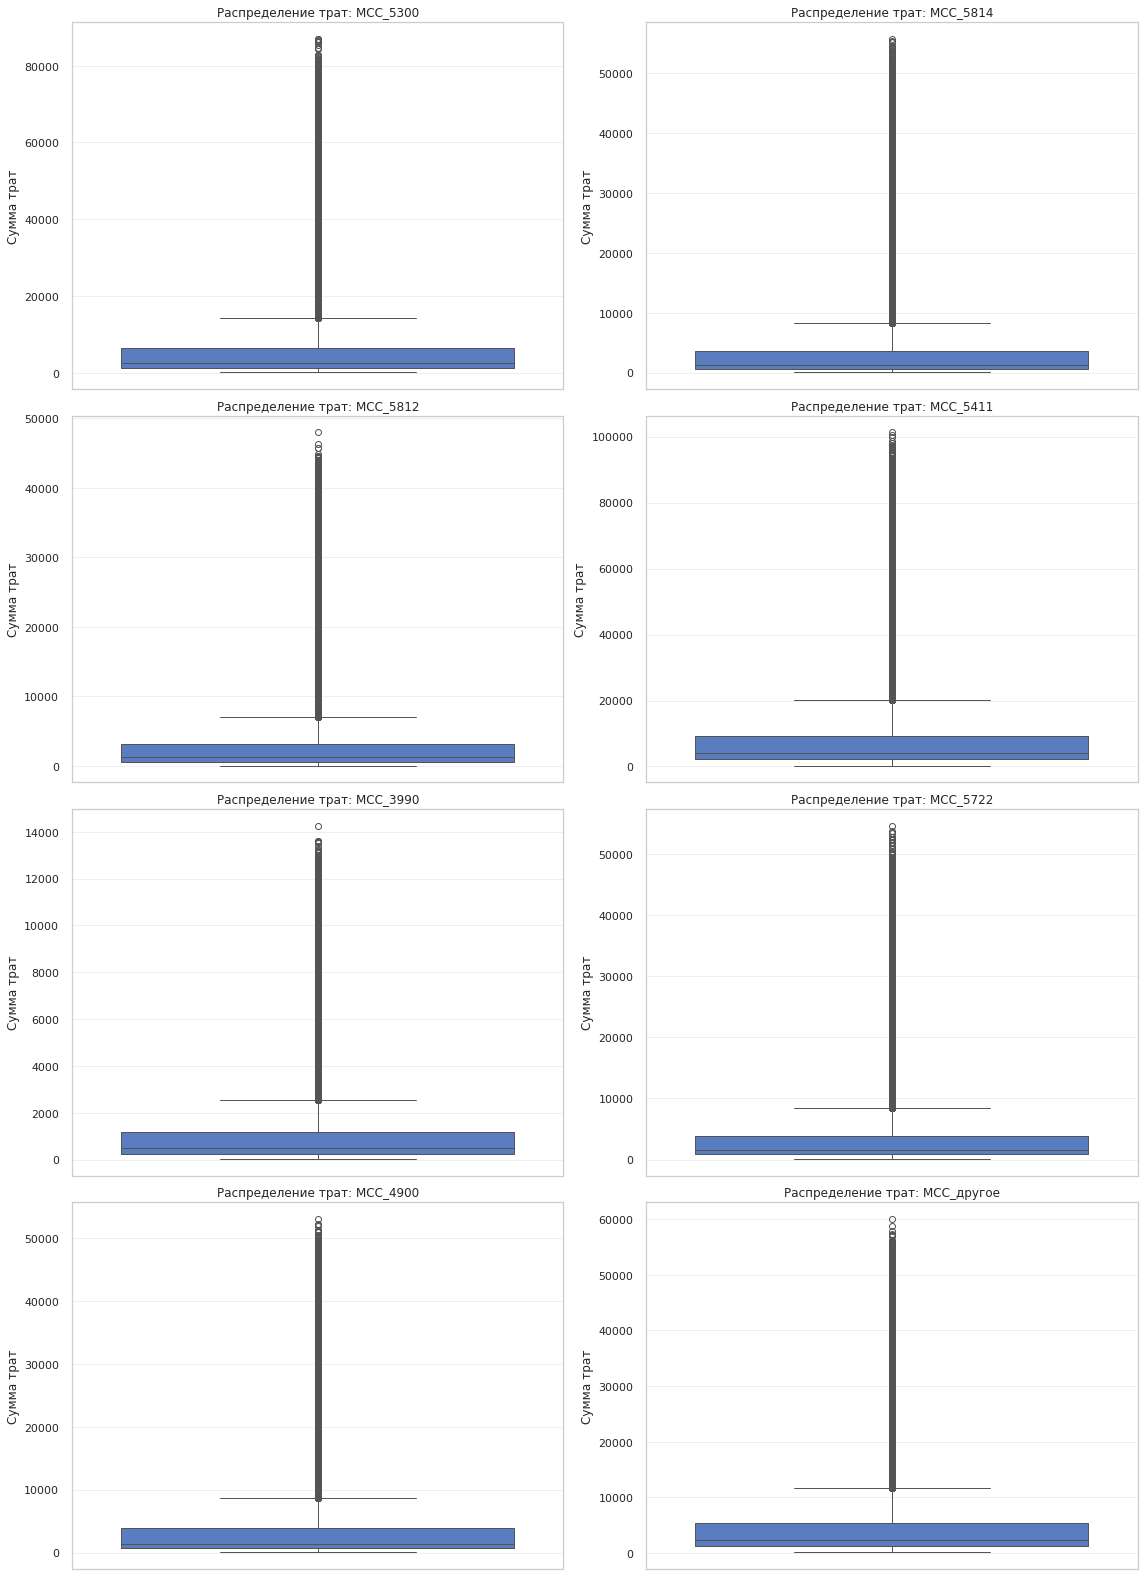

In [13]:
# Столбцы с тратами по MCC-категориям

mcc_columns = [
    'MCC_5300',
    'MCC_5814',
    'MCC_5812',
    'MCC_5411',
    'MCC_3990',
    'MCC_5722',
    'MCC_4900',
    'MCC_другое'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.ravel()

for index, column in enumerate(mcc_columns):
    sns.boxplot(
        y=transactions[column],
        ax=axes[index]
    )
    
    axes[index].set_title(f'Распределение трат: {column}')
    axes[index].set_ylabel('Сумма трат')

plt.tight_layout()
plt.show()

По boxplot-графикам видно, что в тратах по MCC-категориям есть много высоких значений, которые визуально выглядят как выбросы.

На данном этапе не будем их удалять. Для финансовых данных крупные траты могут быть нормальным поведением клиента, а не ошибкой в данных. Позже такие значения могут оказаться полезными для модели.

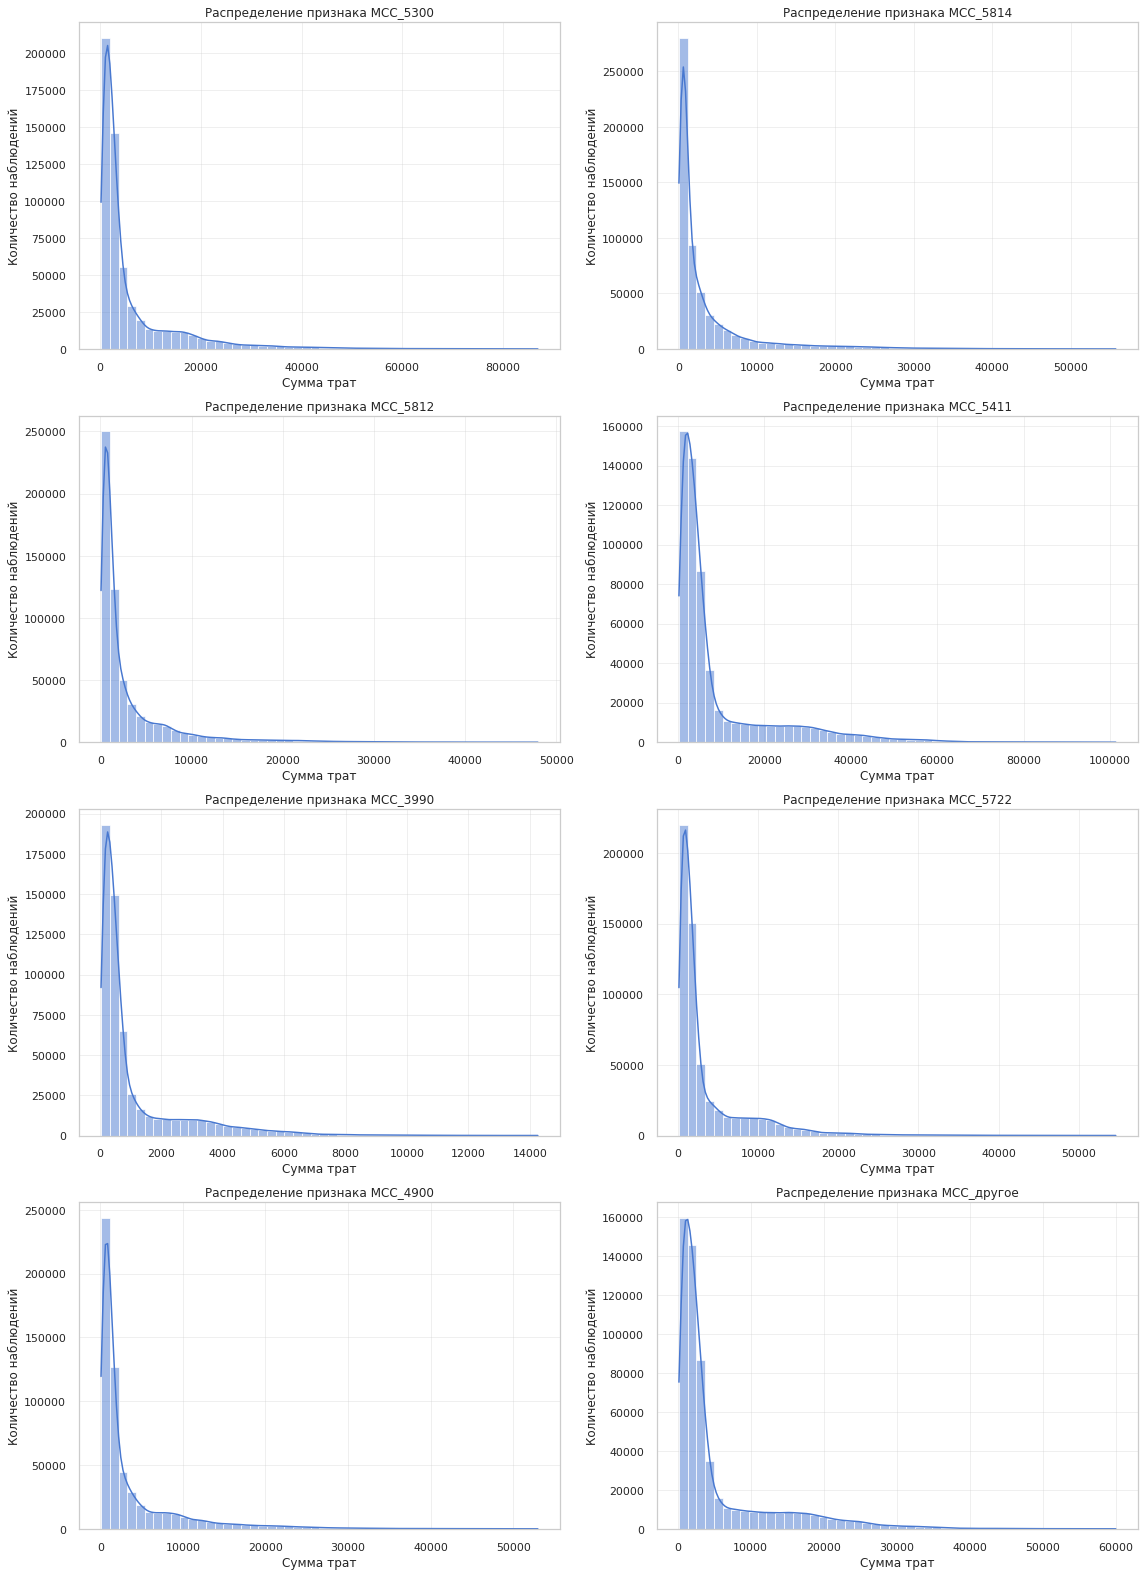

In [14]:
# Распределения трат по MCC-категориям

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.ravel()

for index, column in enumerate(mcc_columns):
    sns.histplot(
        transactions[column],
        bins=50,
        kde=True,
        ax=axes[index]
    )
    
    axes[index].set_title(f'Распределение признака {column}')
    axes[index].set_xlabel('Сумма трат')
    axes[index].set_ylabel('Количество наблюдений')

plt.tight_layout()
plt.show()

Распределения трат заметно скошены вправо: большинство значений находится в относительно небольшом диапазоне, но есть длинный хвост крупных расходов.

Это типичная картина для финансовых транзакций. Такие признаки могут потребовать аккуратной обработки при моделировании, особенно для логистической регрессии.

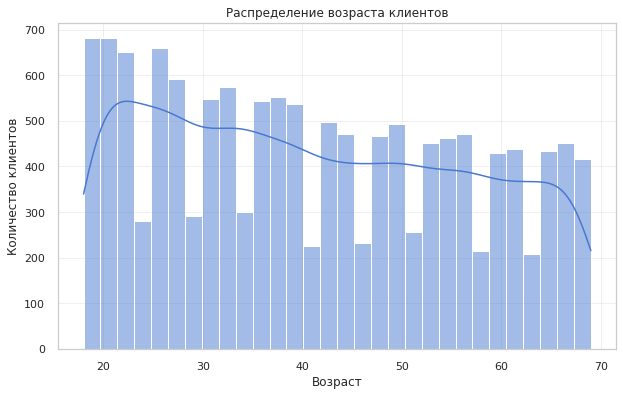

In [15]:
# Распределение возраста клиентов

plt.figure(figsize=(10, 6))

sns.histplot(
    client_description['возраст'],
    bins=30,
    kde=True
)

plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')

plt.show()

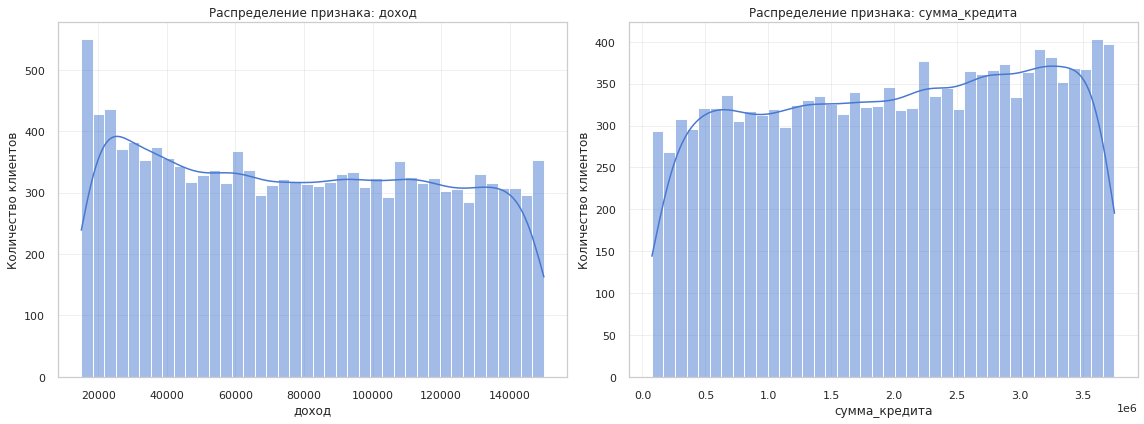

In [16]:
# Распределение дохода и суммы кредита

credit_numeric_columns = ['доход', 'сумма_кредита']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for index, column in enumerate(credit_numeric_columns):
    sns.histplot(
        credit_description[column],
        bins=40,
        kde=True,
        ax=axes[index]
    )
    
    axes[index].set_title(f'Распределение признака: {column}')
    axes[index].set_xlabel(column)
    axes[index].set_ylabel('Количество клиентов')

plt.tight_layout()
plt.show()

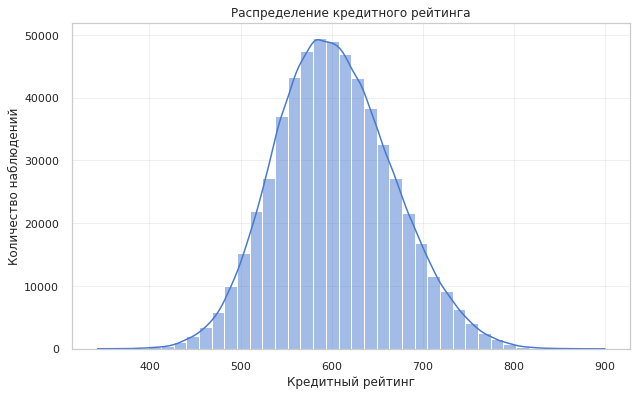

In [17]:
# Распределение кредитного рейтинга

plt.figure(figsize=(10, 6))

sns.histplot(
    credit_rating['кредитный_рейтинг'],
    bins=40,
    kde=True
)

plt.title('Распределение кредитного рейтинга')
plt.xlabel('Кредитный рейтинг')
plt.ylabel('Количество наблюдений')

plt.show()

Возраст, доход, сумма кредита и кредитный рейтинг находятся в понятных диапазонах. На первом просмотре значения не выглядят как технические ошибки.

При этом доход и сумма кредита имеют довольно широкий разброс, что нормально для банковских данных.

In [18]:
# Категориальные признаки клиентов

categorical_columns = [
    'семейное_положение',
    'наличие_иждивенцев'
]

for column in categorical_columns:
    print(f'\nРаспределение признака: {column}')
    display(client_description[column].value_counts())


Распределение признака: семейное_положение


семейное_положение
нет семьи      4584
разведённые    4519
есть семья     4397
Name: count, dtype: int64


Распределение признака: наличие_иждивенцев


наличие_иждивенцев
0    6956
1    6544
Name: count, dtype: int64

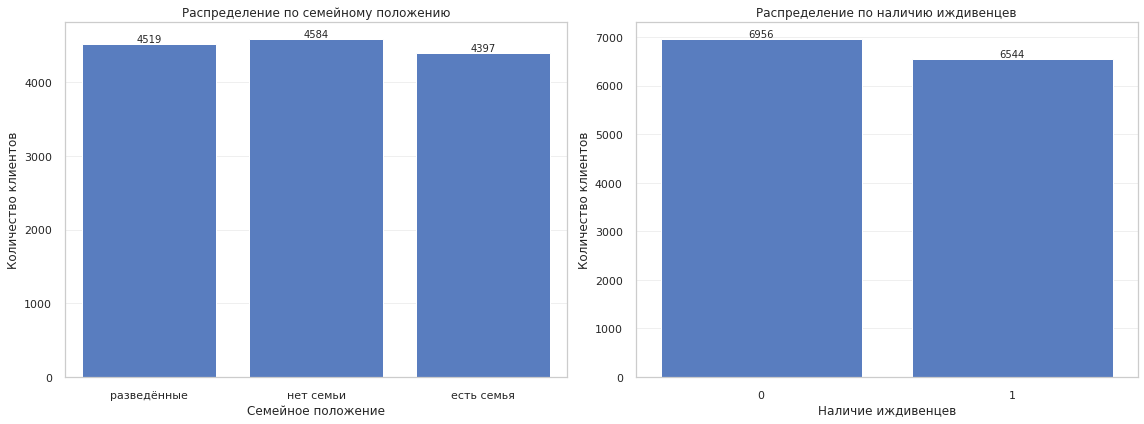

In [19]:
# Графики для категориальных признаков

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=client_description,
    x='семейное_положение',
    ax=axes[0]
)

axes[0].set_title('Распределение по семейному положению')
axes[0].set_xlabel('Семейное положение')
axes[0].set_ylabel('Количество клиентов')

add_bar_labels(axes[0], fmt='{:.0f}')

sns.countplot(
    data=client_description,
    x='наличие_иждивенцев',
    ax=axes[1]
)

axes[1].set_title('Распределение по наличию иждивенцев')
axes[1].set_xlabel('Наличие иждивенцев')
axes[1].set_ylabel('Количество клиентов')

add_bar_labels(axes[1], fmt='{:.0f}')

plt.tight_layout()
plt.show()

Категории семейного положения распределены достаточно равномерно. Признак наличия иждивенцев также не выглядит сильно перекошенным: клиентов с иждивенцами и без них примерно сопоставимое количество.

In [20]:
# Проверим значения признака наличия ипотеки

mortgage_presence['наличие_ипотеки'].value_counts()

наличие_ипотеки
1    6609
Name: count, dtype: int64

В таблице ипотеки присутствуют только клиенты со значением `наличие_ипотеки = 1`. Это логично: сама таблица, судя по структуре, фиксирует факт наличия ипотеки. Клиенты без ипотеки, скорее всего, просто отсутствуют в этой таблице.

При объединении данных это нужно будет учесть: отсутствующая строка по клиенту в таблице ипотеки будет означать отсутствие информации об ипотеке, а не ошибку загрузки.

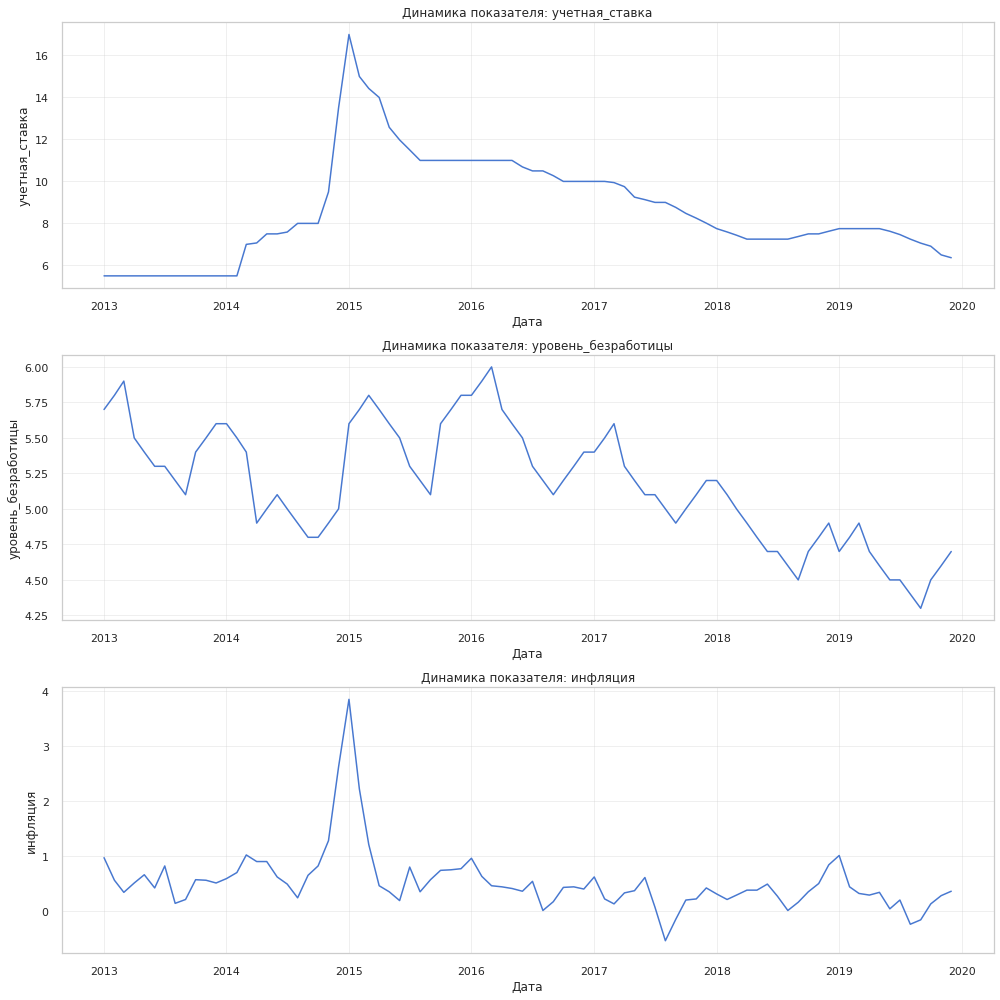

In [21]:
# Динамика макроэкономических показателей

macro_data_plot = macro_data.copy()
macro_data_plot['date'] = pd.to_datetime(macro_data_plot['date'])

macro_columns = [
    'учетная_ставка',
    'уровень_безработицы',
    'инфляция'
]

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for index, column in enumerate(macro_columns):
    sns.lineplot(
        data=macro_data_plot,
        x='date',
        y=column,
        ax=axes[index]
    )
    
    axes[index].set_title(f'Динамика показателя: {column}')
    axes[index].set_xlabel('Дата')
    axes[index].set_ylabel(column)

plt.tight_layout()
plt.show()

Макроэкономические показатели представлены по месяцам. На графиках видно, что значения меняются во времени, поэтому эти признаки могут быть полезны при дальнейшем объединении с датами скоринга.

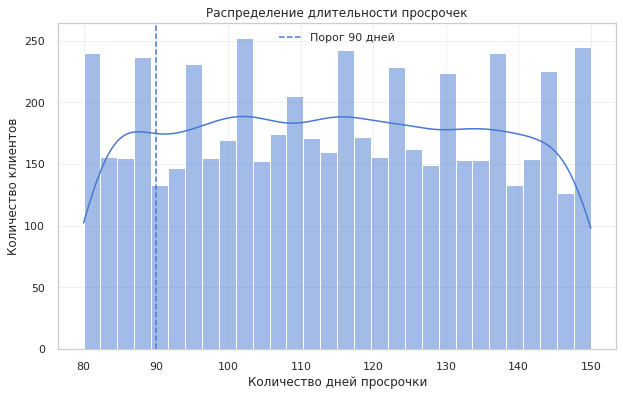

In [22]:
# Распределение длительности просрочек

plt.figure(figsize=(10, 6))

sns.histplot(
    loan_payment['просрочка_дней'],
    bins=30,
    kde=True
)

plt.axvline(
    90,
    linestyle='--',
    label='Порог 90 дней'
)

plt.title('Распределение длительности просрочек')
plt.xlabel('Количество дней просрочки')
plt.ylabel('Количество клиентов')
plt.legend()

plt.show()

In [23]:
# Количество просрочек до 90 дней и от 90 дней

default_90_plus = (
    loan_payment['просрочка_дней'] >= 90
)

default_90_plus.value_counts(normalize=False)

просрочка_дней
True     4712
False     788
Name: count, dtype: int64

In [24]:
# Доли просрочек до 90 дней и от 90 дней

default_90_plus.value_counts(normalize=True)

просрочка_дней
True    0.8567
False   0.1433
Name: proportion, dtype: float64

В таблице просрочек есть записи как с просрочкой менее 90 дней, так и с просрочкой 90 дней и более. Для целевой переменной будут важны именно просрочки от 90 дней.

Временной момент возникновения такого события будет учитываться позже при формировании таргета относительно `score_date`.

In [25]:
# Сводная проверка пропусков и дубликатов по всем таблицам

summary_rows = []

project_tables = {
    'loan_payment': loan_payment,
    'transactions': transactions,
    'client_description': client_description,
    'credit_description': credit_description,
    'mortgage_presence': mortgage_presence,
    'credit_rating': credit_rating,
    'macro_data': macro_data,
    'cohort_grid': cohort_grid
}

for table_name, dataframe in project_tables.items():
    summary_rows.append({
        'table': table_name,
        'rows': dataframe.shape[0],
        'columns': dataframe.shape[1],
        'missing_values': dataframe.isna().sum().sum(),
        'full_duplicates': dataframe.duplicated().sum()
    })

eda_summary = pd.DataFrame(summary_rows)

eda_summary

,table,rows,columns,missing_values,full_duplicates
0,loan_payment,5500,3,0,0
1,transactions,577494,10,0,0
2,client_description,13500,5,0,0
3,credit_description,13500,3,0,0
4,mortgage_presence,6609,3,0,0
5,credit_rating,577494,3,0,0
6,macro_data,84,4,0,0
7,cohort_grid,577494,2,0,0


**Выводы по исследовательскому анализу данных**

По результатам первичного анализа можно сделать следующие выводы:

- пропуски и полные дубликаты в таблицах не обнаружены;
- временные признаки представлены помесячно, даты указаны первым днем месяца;
- в данных используется смесь кириллицы и латиницы в названиях столбцов, но критичных проблем это не создает;
- в транзакционных признаках по MCC-категориям есть много крупных значений и длинные правые хвосты распределений;
- удалять такие значения на текущем этапе не стоит, так как для финансового поведения крупные траты могут быть реальными и информативными;
- возраст, доход, сумма кредита и кредитный рейтинг находятся в разумных диапазонах;
- таблица с ипотекой содержит только клиентов с ипотекой, поэтому при объединении отсутствие клиента в этой таблице нужно будет обработать отдельно;
- макроэкономические показатели меняются во времени и могут быть использованы при формировании итоговой таблицы;
- таблица просрочек содержит как просрочки до 90 дней, так и просрочки 90 дней и более.

Основная особенность проекта связана не с очисткой данных, а с правильной работой со временем. При дальнейшем объединении таблиц нужно будет следить, чтобы признаки описывали только прошлое относительно даты скоринга, а целевая переменная смотрела в будущий горизонт 12 месяцев.

## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [26]:
# Приведем даты к формату datetime

loan_payment['дата_начала_периода'] = pd.to_datetime(
    loan_payment['дата_начала_периода']
)

transactions['date'] = pd.to_datetime(
    transactions['date']
)

client_description['дата_регистрации'] = pd.to_datetime(
    client_description['дата_регистрации']
)

mortgage_presence['дата_открытия'] = pd.to_datetime(
    mortgage_presence['дата_открытия']
)

credit_rating['date'] = pd.to_datetime(
    credit_rating['date']
)

macro_data['date'] = pd.to_datetime(
    macro_data['date']
)

cohort_grid['score_date'] = pd.to_datetime(
    cohort_grid['score_date']
)

print('Все даты успешно приведены к datetime')

Все даты успешно приведены к datetime


In [27]:
# Оставим только просрочки от 90 дней и выше

loan_default_90 = loan_payment[
    loan_payment['просрочка_дней'] >= 90
].copy()

# Для каждого клиента берем первый дефолт

first_default = (
    loan_default_90
    .sort_values('дата_начала_периода')
    .groupby('ID', as_index=False)
    .first()
)

first_default.head()

,ID,дата_начала_периода,просрочка_дней
0,IDF54896351,2014-10-01,93
1,IDF54896494,2019-07-01,137
2,IDF54896677,2017-09-01,90
3,IDF54896685,2017-11-01,136
4,IDF54896744,2019-02-01,97


Для формирования таргета будем использовать только первый эпизод дефолта клиента. Это соответствует логике постановки задачи.

In [28]:
# Создаем основу итоговой таблицы

dataset = cohort_grid.copy()

# Присоединяем дату первого дефолта клиента

dataset = dataset.merge(
    first_default[
        ['ID', 'дата_начала_периода', 'просрочка_дней']
    ],
    on='ID',
    how='left'
)

# Горизонт прогнозирования - 12 месяцев

forecast_horizon = (
    dataset['score_date'] + pd.DateOffset(days=365)
)

# Формируем target

dataset['target'] = (
    (
        dataset['дата_начала_периода']
        >= dataset['score_date']
    )
    &
    (
        dataset['дата_начала_периода']
        < forecast_horizon
    )
).astype(int)

dataset.head()

,ID,score_date,дата_начала_периода,просрочка_дней,target
0,IDF55109846,2013-05-01,2014-12-01,120.0000,0
1,IDF55109846,2013-06-01,2014-12-01,120.0000,0
2,IDF55109846,2013-07-01,2014-12-01,120.0000,0
3,IDF55109846,2013-08-01,2014-12-01,120.0000,0
4,IDF55109846,2013-09-01,2014-12-01,120.0000,0


Теперь каждая строка показывает, случится ли у клиента дефолт в течение ближайших 12 месяцев после даты скоринга.

In [29]:
# Удаляем строки, где дефолт уже произошел до даты скоринга

dataset = dataset[
    (
        dataset['дата_начала_периода'].isna()
    )
    |
    (
        dataset['дата_начала_периода']
        >= dataset['score_date']
    )
].copy()

dataset.shape

(438379, 5)

In [30]:
# Для строк без target очищаем информацию о будущем дефолте, чтобы избежать утечки

target_zero_mask = dataset['target'] == 0

dataset.loc[
    target_zero_mask,
    'дата_начала_периода'
] = pd.NaT

dataset.loc[
    target_zero_mask,
    'просрочка_дней'
] = np.nan

Если дефолт уже произошел раньше даты скоринга, такую строку нельзя использовать для обучения модели. Иначе возникнет утечка информации из будущего.

**Создание итоговой таблицы**

Теперь присоединим признаки.

Для временных таблиц важно использовать только прошлые данные относительно `score_date`.

In [31]:
# Создаем дату предыдущего месяца, она понадобится для присоединения транзакций, рейтингов и макроэкономики

dataset['prev_month_date'] = (
    dataset['score_date']
    - pd.DateOffset(months=1)
)

dataset.head()

,ID,score_date,дата_начала_периода,просрочка_дней,target,prev_month_date
0,IDF55109846,2013-05-01,NaT,NaN,0,2013-04-01
1,IDF55109846,2013-06-01,NaT,NaN,0,2013-05-01
2,IDF55109846,2013-07-01,NaT,NaN,0,2013-06-01
3,IDF55109846,2013-08-01,NaT,NaN,0,2013-07-01
4,IDF55109846,2013-09-01,NaT,NaN,0,2013-08-01


In [32]:
# Добавляем транзакции за предыдущий месяц

dataset = dataset.merge(
    transactions,
    left_on=['ID', 'prev_month_date'],
    right_on=['ID', 'date'],
    how='left'
)

dataset.shape

(438379, 15)

In [33]:
# Добавляем информацию о клиентах

dataset = dataset.merge(
    client_description,
    on='ID',
    how='left'
)

dataset.shape

(438379, 19)

In [34]:
# Добавляем описание кредита

dataset = dataset.merge(
    credit_description,
    on='ID',
    how='left'
)

dataset.shape

(438379, 21)

In [35]:
# Добавляем данные об ипотеке

dataset = dataset.merge(
    mortgage_presence,
    on='ID',
    how='left'
)

# Если ипотека открыта после даты скоринга, такую информацию использовать нельзя

future_mortgage_mask = (
    dataset['дата_открытия'] > dataset['score_date']
)

dataset.loc[
    future_mortgage_mask,
    'наличие_ипотеки'
] = 0

dataset.loc[
    future_mortgage_mask,
    'дата_открытия'
] = pd.NaT

# Если записи нет - считаем, что ипотеки нет

dataset['наличие_ипотеки'] = (
    dataset['наличие_ипотеки']
    .fillna(0)
)

dataset.shape

(438379, 23)

In [36]:
# Проверяем, что после обработки
# не осталось ипотек из будущего

future_mortgage_check = dataset[
    dataset['дата_открытия'] > dataset['score_date']
]

print(
    f'Количество ипотек из будущего: '
    f'{len(future_mortgage_check)}'
)

Количество ипотек из будущего: 0


In [37]:
# Добавляем кредитный рейтинг только за предыдущий месяц

dataset = dataset.merge(
    credit_rating,
    left_on=['ID', 'prev_month_date'],
    right_on=['ID', 'date'],
    how='left'
)

dataset.shape

(438379, 25)

In [38]:
# Добавляем макроэкономические показатели

dataset = dataset.merge(
    macro_data,
    left_on='prev_month_date',
    right_on='date',
    how='left'
)

# Удаляем технические колонки дат, появившиеся после объединений

dataset = dataset.drop(
    columns=['date_x', 'date_y', 'date']
)

dataset.shape

(438379, 26)

In [39]:
# Общая информация по итоговой таблице

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 26 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   438379 non-null  object        
 1   score_date           438379 non-null  datetime64[ns]
 2   дата_начала_периода  49364 non-null   datetime64[ns]
 3   просрочка_дней       49364 non-null   float64       
 4   target               438379 non-null  int64         
 5   prev_month_date      438379 non-null  datetime64[ns]
 6   MCC_5300             424879 non-null  float64       
 7   MCC_5814             424879 non-null  float64       
 8   MCC_5812             424879 non-null  float64       
 9   MCC_5411             424879 non-null  float64       
 10  MCC_3990             424879 non-null  float64       
 11  MCC_5722             424879 non-null  float64       
 12  MCC_4900             424879 non-null  float64       
 13  MCC_другое    

In [40]:
# Посмотрим на итоговую таблицу

display(dataset.head())

,ID,score_date,дата_начала_периода,просрочка_дней,target,prev_month_date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,NaT,NaN,0,2013-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41,разведённые,1,2013-05-01,27035,1960785,NaT,0.0000,NaN,5.5000,5.5000,0.5100
1,IDF55109846,2013-06-01,NaT,NaN,0,2013-05-01,3267.5900,1282.1100,1457.9600,5711.1000,647.4300,2374.7800,4059.8600,3657.3500,41,разведённые,1,2013-05-01,27035,1960785,NaT,0.0000,692.0000,5.5000,5.4000,0.6600
2,IDF55109846,2013-07-01,NaT,NaN,0,2013-06-01,3196.5800,2443.3700,1334.2000,5824.6500,1067.5500,2187.1100,4592.2600,3322.6100,41,разведённые,1,2013-05-01,27035,1960785,NaT,0.0000,688.0000,5.5000,5.3000,0.4200
3,IDF55109846,2013-08-01,NaT,NaN,0,2013-07-01,3550.5400,4277.7200,1463.7500,5209.5100,1167.9500,2076.5400,3605.2500,3467.0600,41,разведённые,1,2013-05-01,27035,1960785,NaT,0.0000,666.0000,5.5000,5.3000,0.8200
4,IDF55109846,2013-09-01,NaT,NaN,0,2013-08-01,3385.9800,4530.6300,1261.4000,5765.9600,986.9900,2231.7700,2209.3900,3354.4400,41,разведённые,1,2013-05-01,27035,1960785,NaT,0.0000,692.0000,5.5000,5.2000,0.1400


После объединения получили единую таблицу наблюдений, где:
- каждая строка соответствует клиенту в конкретный месяц;
- target показывает риск дефолта в будущем;
- признаки описывают только прошлое относительно даты скоринга.

In [41]:
# Проверим распределение target

dataset['target'].value_counts()

target
0    389015
1     49364
Name: count, dtype: int64

In [42]:
# Доли классов target

dataset['target'].value_counts(normalize=True)

target
0   0.8874
1   0.1126
Name: proportion, dtype: float64

In [43]:
# Проверим корректность данных на одном клиенте

example_client = 'IDF55109846'

print('=' * 60)
print('Данные клиента')
print('=' * 60)

display(
    dataset[
        dataset['ID'] == example_client
    ][[
        'ID',
        'score_date',
        'дата_начала_периода',
        'target',
        'кредитный_рейтинг',
        'учетная_ставка'
    ]].head(15)
)

Данные клиента


,ID,score_date,дата_начала_периода,target,кредитный_рейтинг,учетная_ставка
0,IDF55109846,2013-05-01,NaT,0,NaN,5.5000
1,IDF55109846,2013-06-01,NaT,0,692.0000,5.5000
2,IDF55109846,2013-07-01,NaT,0,688.0000,5.5000
3,IDF55109846,2013-08-01,NaT,0,666.0000,5.5000
4,IDF55109846,2013-09-01,NaT,0,692.0000,5.5000
5,IDF55109846,2013-10-01,NaT,0,688.0000,5.5000
6,IDF55109846,2013-11-01,NaT,0,669.0000,5.5000
7,IDF55109846,2013-12-01,NaT,0,658.0000,5.5000
8,IDF55109846,2014-01-01,2014-12-01,1,656.0000,5.5000
9,IDF55109846,2014-02-01,2014-12-01,1,655.0000,5.5000


**Выводы по объединению таблиц**

В результате объединения была сформирована единая таблица наблюдений для задачи поведенческого скоринга.

Основные особенности итогового датасета:

- каждая строка описывает состояние клиента на конкретную дату скоринга;
- целевая переменная учитывает возникновение дефолта в течение следующих 12 месяцев;
- признаки формировались только на основе прошлых данных относительно `score_date`;
- для транзакций, кредитного рейтинга и макроэкономики использовались значения предыдущего месяца;
- строки с уже произошедшим дефолтом были удалены для сохранения корректной временной структуры.

Также видно, что целевая переменная несбалансирована: клиентов без дефолта заметно больше, чем клиентов с дефолтом. Это нужно будет учитывать на этапе моделирования.

Доля дефолтов составляет около 11%, поэтому при обучении моделей нужно будет учитывать дисбаланс классов. Например, с помощью стратификации, class_weight или подходящих метрик качества.

## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

На этом этапе добавляем новые признаки, которые помогут модели лучше описывать финансовое поведение клиентов.

Также удалим признаки, содержащие информацию о будущем относительно даты скоринга. Такие столбцы нельзя использовать при обучении модели, иначе возникнет утечка данных.

In [44]:
# Создаем рабочую копию итоговой таблицы

model_data = dataset.copy()

model_data.shape

(438379, 26)

In [45]:
# Удаляем признаки, содержащие информацию о будущем

model_data = model_data.drop(
    columns=[
        'дата_начала_периода',
        'просрочка_дней'
    ]
)

model_data.shape

(438379, 24)

Столбцы `дата_начала_периода` и `просрочка_дней` напрямую связаны с будущим дефолтом клиента. Использовать их в модели нельзя, поэтому удаляем их до этапа моделирования.

In [46]:
# Добавляем признак длительности ипотеки в месяцах

model_data['месяцев_с_ипотекой'] = (
    (
        model_data['score_date']
        - model_data['дата_открытия']
    ).dt.days / 30
)

# Для клиентов без ипотеки используем специальное значение

model_data['месяцев_с_ипотекой'] = (
    model_data['месяцев_с_ипотекой']
    .fillna(-1)
)

# Исходную дату открытия ипотеки удаляем

model_data = model_data.drop(
    columns='дата_открытия'
)

model_data['месяцев_с_ипотекой'].describe()

count   438379.0000
mean        11.9897
std         19.3014
min         -1.0000
25%         -1.0000
50%         -1.0000
75%         20.2333
max         84.1667
Name: месяцев_с_ипотекой, dtype: float64

Новый признак показывает, как давно у клиента оформлена ипотека.

Для клиентов без ипотеки используется значение *-1*. Это позволит модели отличать отсутствие ипотеки от недавно открытой ипотеки.

In [47]:
# Добавляем признак длительности отношений с банком

model_data['месяцев_в_банке'] = (
    (
        model_data['score_date']
        - model_data['дата_регистрации']
    ).dt.days / 30
)

# После создания признака удаляем исходную дату регистрации

model_data = model_data.drop(
    columns='дата_регистрации'
)

model_data['месяцев_в_банке'].describe()

count   438379.0000
mean        25.1453
std         20.1271
min          0.0000
25%          8.1333
50%         20.2333
75%         39.5000
max         84.1667
Name: месяцев_в_банке, dtype: float64

Признак `месяцев_в_банке` показывает, как долго клиент взаимодействует с банком.

Продолжительность отношений с банком может быть полезным сигналом: поведение новых клиентов и клиентов с длинной историей часто отличается.

In [48]:
# Добавим общий объем ежемесячных трат

mcc_columns = [
    'MCC_5300',
    'MCC_5814',
    'MCC_5812',
    'MCC_5411',
    'MCC_3990',
    'MCC_5722',
    'MCC_4900',
    'MCC_другое'
]

model_data['общие_траты'] = (
    model_data[mcc_columns]
    .fillna(0)
    .sum(axis=1)
)

model_data['общие_траты'].describe()

count   438379.0000
mean     42967.1367
std      51420.2906
min          0.0000
25%       9535.3600
50%      18804.1200
75%      61462.2600
max     309029.0800
Name: общие_траты, dtype: float64

Признак `общие_траты` агрегирует транзакционную активность клиента за месяц.

Он может помочь модели оценивать общий уровень финансовой активности клиента.

In [49]:
# Отношение суммы кредита к доходу клиента

model_data['долговая_нагрузка'] = (
    model_data['сумма_кредита']
    / model_data['доход']
)

model_data['долговая_нагрузка'].describe()

count   438379.0000
mean        34.7974
std         35.4066
min          0.5062
25%         12.4627
50%         23.8530
75%         42.8384
max        242.9706
Name: долговая_нагрузка, dtype: float64

Признак `долговая_нагрузка` показывает отношение суммы кредита к доходу клиента.

Высокая долговая нагрузка потенциально может быть связана с повышенным риском дефолта.

In [50]:
# Переведем бинарные признаки в bool

model_data['наличие_иждивенцев'] = (
    model_data['наличие_иждивенцев']
    .astype(bool)
)

model_data['наличие_ипотеки'] = (
    model_data['наличие_ипотеки']
    .astype(bool)
)

Булево будет удобно для дальнейшей обработки категориальных признаков в пайплайне.

In [51]:
# Проверим структуру итоговой таблицы

model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 26 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   438379 non-null  object        
 1   score_date           438379 non-null  datetime64[ns]
 2   target               438379 non-null  int64         
 3   prev_month_date      438379 non-null  datetime64[ns]
 4   MCC_5300             424879 non-null  float64       
 5   MCC_5814             424879 non-null  float64       
 6   MCC_5812             424879 non-null  float64       
 7   MCC_5411             424879 non-null  float64       
 8   MCC_3990             424879 non-null  float64       
 9   MCC_5722             424879 non-null  float64       
 10  MCC_4900             424879 non-null  float64       
 11  MCC_другое           424879 non-null  float64       
 12  возраст              438379 non-null  int64         
 13  семейное_полож

**Итоговый набор признаков**

После генерации новых признаков получили итоговую таблицу для моделирования.

В наборе присутствуют:

- транзакционные признаки по MCC-категориям;
- социально-демографические характеристики клиентов;
- кредитные параметры;
- макроэкономические показатели;
- новые поведенческие признаки.

Для модели:
- `target` остается целевой переменной;
- `ID` и `score_date` понадобятся для временной валидации и группировок;
- категориальные признаки позже будут закодированы через пайплайн.

**Выводы по новым признакам**

На этапе feature engineering были созданы признаки, которые помогают лучше описывать поведение клиентов и их финансовую нагрузку.

Добавленные признаки отражают:
- длительность отношений с банком;
- наличие и длительность ипотеки;
- общий объем трат;
- отношение кредита к доходу клиента.

При этом признаки, содержащие информацию о будущем дефолте, были удалены до этапа моделирования, чтобы избежать утечки данных.

## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

Проведем краткий анализ итоговой таблицы `model_data`, которую будем использовать для моделирования.

На этом этапе посмотрим на размер данных, пропуски, типы признаков и распределение целевой переменной. Отдельно оценим дисбаланс классов, так как для задачи дефолта это один из ключевых моментов.

In [52]:
# Размер итоговой таблицы

print(f'Количество строк: {model_data.shape[0]}')
print(f'Количество столбцов: {model_data.shape[1]}')

Количество строк: 438379
Количество столбцов: 26


In [53]:
# Общая информация по итоговой таблице

model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 26 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   438379 non-null  object        
 1   score_date           438379 non-null  datetime64[ns]
 2   target               438379 non-null  int64         
 3   prev_month_date      438379 non-null  datetime64[ns]
 4   MCC_5300             424879 non-null  float64       
 5   MCC_5814             424879 non-null  float64       
 6   MCC_5812             424879 non-null  float64       
 7   MCC_5411             424879 non-null  float64       
 8   MCC_3990             424879 non-null  float64       
 9   MCC_5722             424879 non-null  float64       
 10  MCC_4900             424879 non-null  float64       
 11  MCC_другое           424879 non-null  float64       
 12  возраст              438379 non-null  int64         
 13  семейное_полож

In [54]:
# Проверим пропуски в итоговой таблице

missing_summary = (
    model_data
    .isna()
    .sum()
    .to_frame(name='missing_values')
)

missing_summary['missing_share'] = (
    missing_summary['missing_values']
    / len(model_data)
)

missing_summary = (
    missing_summary
    .query('missing_values > 0')
    .sort_values('missing_share', ascending=False)
)

missing_summary

,missing_values,missing_share
MCC_5300,13500,0.0308
MCC_5814,13500,0.0308
MCC_5812,13500,0.0308
MCC_5411,13500,0.0308
MCC_3990,13500,0.0308
MCC_5722,13500,0.0308
MCC_4900,13500,0.0308
MCC_другое,13500,0.0308
кредитный_рейтинг,13500,0.0308
учетная_ставка,152,0.0003


В итоговой таблице могут оставаться пропуски в признаках, которые присоединялись по предыдущему месяцу. Например, для самых первых дат скоринга у клиента может не быть транзакций или кредитного рейтинга за предыдущий месяц.

На этапе моделирования такие пропуски нужно будет обработать внутри пайплайна, чтобы избежать ручной обработки данных до разделения на выборки.

In [55]:
# Распределение целевой переменной

target_counts = (
    model_data['target']
    .value_counts()
    .sort_index()
    .to_frame(name='count')
)

target_counts['share'] = (
    target_counts['count']
    / target_counts['count'].sum()
)

target_counts

,count,share
target,,
0,389015,0.8874
1,49364,0.1126


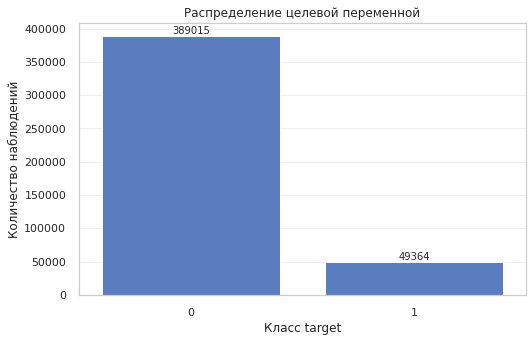

In [56]:
# Визуализируем баланс классов

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=model_data,
    x='target'
)

plt.title('Распределение целевой переменной')
plt.xlabel('Класс target')
plt.ylabel('Количество наблюдений')

add_bar_labels(ax, fmt='{:.0f}')

plt.show()

In [57]:
# Оценим соотношение классов

class_0_count = target_counts.loc[0, 'count']
class_1_count = target_counts.loc[1, 'count']

class_ratio = class_0_count / class_1_count

print(f'Объектов класса 0 больше примерно в {class_ratio:.1f} раза')

Объектов класса 0 больше примерно в 7.9 раза


In [58]:
# Разделим признаки по типам для будущего пайплайна

target_column = 'target'

technical_columns = [
    'ID',
    'score_date',
    'prev_month_date'
]

categorical_features = [
    'семейное_положение',
    'наличие_иждивенцев',
    'наличие_ипотеки'
]

numeric_features = [
    column for column in model_data.columns
    if column not in technical_columns
    and column not in categorical_features
    and column != target_column
]

print(f'Количество числовых признаков: {len(numeric_features)}')
print(f'Количество категориальных признаков: {len(categorical_features)}')

print('\nЧисловые признаки:')
print(numeric_features)

print('\nКатегориальные признаки:')
print(categorical_features)

Количество числовых признаков: 19
Количество категориальных признаков: 3

Числовые признаки:
['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'возраст', 'доход', 'сумма_кредита', 'кредитный_рейтинг', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'месяцев_с_ипотекой', 'месяцев_в_банке', 'общие_траты', 'долговая_нагрузка']

Категориальные признаки:
['семейное_положение', 'наличие_иждивенцев', 'наличие_ипотеки']


**Выводы по итоговой таблице**

Итоговая таблица готова для дальнейшей подготовки к моделированию.

Основные наблюдения:

- каждая строка описывает клиента на конкретную дату скоринга;
- в таблице 438 379 строк и 26 столбцов;
- признаки с информацией о будущем дефолте были удалены;
- технические поля `ID`, `score_date` и `prev_month_date` понадобятся для временного разделения и проверок, но не должны напрямую использоваться как признаки модели;
- в транзакционных признаках и кредитном рейтинге есть пропуски примерно в 3.08% строк;
- в макроэкономических признаках доля пропусков минимальная - около 0.03%;
- пропуски лучше обрабатывать внутри пайплайна после разделения данных на выборки;
- для будущего пайплайна выделено 19 числовых и 3 категориальных признака;
- целевая переменная заметно несбалансирована: класс `0` занимает 88.74%, класс `1` - 11.26%;
- объектов класса `0` примерно в 7.9 раза больше, чем объектов класса `1`.

Так как дефолтный класс встречается заметно реже, при обучении моделей нужно будет использовать стратегии работы с дисбалансом. В качестве базовых вариантов можно проверить `class_weight` и андерсемплинг, так как строк в данных достаточно много.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

In [59]:
# Сортируем данные по дате скоринга

model_data = model_data.sort_values('score_date').reset_index(drop=True)

In [60]:
# Определяем временные границы выборок

max_score_date = model_data['score_date'].max()

# Тестовая выборка - последние 12 месяцев
test_start_date = max_score_date - pd.DateOffset(months=11)
test_start_date = pd.Timestamp(
    year=test_start_date.year,
    month=test_start_date.month,
    day=1
)

# Калибровочная выборка - 12 месяцев перед тестом
calibration_end_date = test_start_date - pd.DateOffset(days=1)
calibration_start_date = calibration_end_date - pd.DateOffset(months=11)
calibration_start_date = pd.Timestamp(
    year=calibration_start_date.year,
    month=calibration_start_date.month,
    day=1
)

train_data = model_data[
    model_data['score_date'] < calibration_start_date
].copy()

calibration_data = model_data[
    (model_data['score_date'] >= calibration_start_date)
    &
    (model_data['score_date'] <= calibration_end_date)
].copy()

test_data = model_data[
    model_data['score_date'] >= test_start_date
].copy()

In [61]:
# Проверим размеры выборок

print(f'Обучающая выборка: {train_data.shape[0]} строк')
print(f'Калибровочная выборка: {calibration_data.shape[0]} строк')
print(f'Тестовая выборка: {test_data.shape[0]} строк')
print(f'Всего строк: {train_data.shape[0] + calibration_data.shape[0] + test_data.shape[0]}')

Обучающая выборка: 240401 строк
Калибровочная выборка: 94295 строк
Тестовая выборка: 103683 строк
Всего строк: 438379


In [62]:
# Проверим диапазоны дат

print('Диапазоны дат в выборках:')
print(f"Обучающая: {train_data['score_date'].min()} - {train_data['score_date'].max()}")
print(f"Калибровочная: {calibration_data['score_date'].min()} - {calibration_data['score_date'].max()}")
print(f"Тестовая: {test_data['score_date'].min()} - {test_data['score_date'].max()}")

Диапазоны дат в выборках:
Обучающая: 2013-01-01 00:00:00 - 2017-12-01 00:00:00
Калибровочная: 2018-01-01 00:00:00 - 2018-12-01 00:00:00
Тестовая: 2019-01-01 00:00:00 - 2019-12-01 00:00:00


In [63]:
# Проверим распределение целевой переменной

print('Распределение target:')
print('Обучающая:', train_data['target'].value_counts(normalize=True).to_dict())
print('Калибровочная:', calibration_data['target'].value_counts(normalize=True).to_dict())
print('Тестовая:', test_data['target'].value_counts(normalize=True).to_dict())

Распределение target:
Обучающая: {0: 0.8589148963606641, 1: 0.14108510363933593}
Калибровочная: {0: 0.8892093960443289, 1: 0.11079060395567103}
Тестовая: {0: 0.9517760867258857, 1: 0.04822391327411437}


Доля дефолтов может отличаться между временными выборками. Это нормально для поведенческого скоринга: финансовое поведение клиентов и макроэкономическая среда меняются со временем.

Именно поэтому важно проверять качество модели не только на кросс-валидации, но и на отдельной тестовой выборке из более позднего периода.

In [64]:
# Формируем список признаков

feature_columns = [
    column for column in model_data.columns
    if column not in technical_columns
    and column != target_column
]

X_train = train_data[feature_columns]
y_train = train_data[target_column]

X_calibration = calibration_data[feature_columns]
y_calibration = calibration_data[target_column]

X_test = test_data[feature_columns]
y_test = test_data[target_column]

print(f'X_train: {X_train.shape}')
print(f'X_calibration: {X_calibration.shape}')
print(f'X_test: {X_test.shape}')

X_train: (240401, 22)
X_calibration: (94295, 22)
X_test: (103683, 22)


In [65]:
# Разделим признаки для пайплайна

cat_features = [
    'семейное_положение'
]

bool_features = [
    'наличие_иждивенцев',
    'наличие_ипотеки'
]

num_features = [
    column for column in numeric_features
    if column in feature_columns
]

print(f'Числовые признаки: {len(num_features)}')
print(f'Категориальные признаки: {len(cat_features)}')
print(f'Булевы признаки: {len(bool_features)}')

Числовые признаки: 19
Категориальные признаки: 1
Булевы признаки: 2


In [66]:
# Пайплайн предобработки признаков

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]
            ),
            num_features
        ),
        (
            'cat',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
                ]
            ),
            cat_features
        ),
        (
            'bool',
            'passthrough',
            bool_features
        )
    ],
    remainder='drop'
)

In [67]:
# Функции для создания обычного и imbalanced-пайплайна

def build_pipeline(model):
    return Pipeline(
        steps=[
            ('preprocessing', preprocessor),
            ('model', model)
        ]
    )


def build_imb_pipeline(model):
    return ImbPipeline(
        steps=[
            ('preprocessing', preprocessor),
            ('sampler', RandomUnderSampler(random_state=RANDOM_STATE)),
            ('model', model)
        ]
    )

In [68]:
# Функция для расчета бизнес-метрик

def calculate_business_metrics(y_true, y_pred, y_proba=None):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    approval_rate = (tn + fn) / len(y_true)
    default_rate = fn / (tn + fn) if (tn + fn) > 0 else 0
    missed_defaults_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate
    }

    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)

    return metrics

In [69]:
# Кросс-валидация по временным группам

cv_splitter = GroupTimeSeriesSplit(
    test_size=12,
    train_size=36,
    gap_size=0,
    shift_size=12
)

groups_train = train_data['score_date']

In [70]:
# Функция для кросс-валидации и сбора метрик

cv_results = pd.DataFrame()

def evaluate_model_cv(pipeline, model_name, X=X_train, y=y_train, groups=groups_train):

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    for fold_number, (train_index, valid_index) in enumerate(
        cv_splitter.split(X, y, groups=groups),
        start=1
    ):

        X_train_fold = X.iloc[train_index]
        X_valid_fold = X.iloc[valid_index]

        y_train_fold = y.iloc[train_index]
        y_valid_fold = y.iloc[valid_index]

        pipeline.fit(X_train_fold, y_train_fold)

        y_pred_fold = pipeline.predict(X_valid_fold)

        y_true_all.extend(y_valid_fold)
        y_pred_all.extend(y_pred_fold)

        if hasattr(pipeline, 'predict_proba'):
            y_proba_fold = pipeline.predict_proba(X_valid_fold)[:, 1]
            y_proba_all.extend(y_proba_fold)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    if len(y_proba_all) > 0:
        y_proba_all = np.array(y_proba_all)
    else:
        y_proba_all = None

    metrics = calculate_business_metrics(
        y_true=y_true_all,
        y_pred=y_pred_all,
        y_proba=y_proba_all
    )

    cv_results.loc[model_name, 'accuracy'] = metrics['accuracy']
    cv_results.loc[model_name, 'roc_auc'] = metrics.get('roc_auc', np.nan)
    cv_results.loc[model_name, 'approval_rate'] = metrics['approval_rate']
    cv_results.loc[model_name, 'default_rate'] = metrics['default_rate']
    cv_results.loc[model_name, 'missed_defaults_rate'] = metrics['missed_defaults_rate']

    display(
        cv_results
        .sort_values('missed_defaults_rate')
    )

    return metrics

In [71]:
# Базовая логистическая регрессия без балансировки

base_logreg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

base_logreg_pipeline = build_pipeline(base_logreg)

evaluate_model_cv(
    pipeline=base_logreg_pipeline,
    model_name='base_logreg'
)

,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
base_logreg,0.8879,0.8782,0.9734,0.1003,0.8899


{'accuracy': 0.8878506616388124,
 'approval_rate': 0.9734374025217831,
 'default_rate': 0.10033397184382366,
 'missed_defaults_rate': 0.8899134718625655,
 'roc_auc': 0.8781543770092477}

In [72]:
# Базовый случайный лес без балансировки

base_forest = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

base_forest_pipeline = build_pipeline(base_forest)

evaluate_model_cv(
    pipeline=base_forest_pipeline,
    model_name='base_random_forest'
)

,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
base_random_forest,0.9014,0.9155,0.9554,0.0857,0.7458
base_logreg,0.8879,0.8782,0.9734,0.1003,0.8899


{'accuracy': 0.9014438906718979,
 'approval_rate': 0.955393967961293,
 'default_rate': 0.08567199698174537,
 'missed_defaults_rate': 0.7457841217709846,
 'roc_auc': 0.9155203146951264}

In [73]:
# Логистическая регрессия с андерсемплингом

balanced_logreg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

balanced_logreg_pipeline = build_imb_pipeline(balanced_logreg)

evaluate_model_cv(
    pipeline=balanced_logreg_pipeline,
    model_name='balanced_logreg_under'
)

,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
balanced_logreg_under,0.8019,0.8800,0.7365,0.0301,0.2020
base_random_forest,0.9014,0.9155,0.9554,0.0857,0.7458
base_logreg,0.8879,0.8782,0.9734,0.1003,0.8899


{'accuracy': 0.8018826726187588,
 'approval_rate': 0.7364674240796324,
 'default_rate': 0.03010024001129465,
 'missed_defaults_rate': 0.20198319964630834,
 'roc_auc': 0.8800199671275981}

In [74]:
# Случайный лес с андерсемплингом

balanced_forest = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

balanced_forest_pipeline = build_imb_pipeline(balanced_forest)

evaluate_model_cv(
    pipeline=balanced_forest_pipeline,
    model_name='balanced_random_forest_under'
)

,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
balanced_random_forest_under,0.8383,0.9096,0.7724,0.0284,0.2000
balanced_logreg_under,0.8019,0.8800,0.7365,0.0301,0.2020
base_random_forest,0.9014,0.9155,0.9554,0.0857,0.7458
base_logreg,0.8879,0.8782,0.9734,0.1003,0.8899


{'accuracy': 0.8382884038180268,
 'approval_rate': 0.772429521083022,
 'default_rate': 0.028411691330216364,
 'missed_defaults_rate': 0.19996210446535717,
 'roc_auc': 0.9095766269442208}

**Выводы по базовым моделям**

На базовом сравнении проверены четыре варианта:

- логистическая регрессия без балансировки;
- случайный лес без балансировки;
- логистическая регрессия с андерсемплингом;
- случайный лес с андерсемплингом.

Модели без балансировки обычно показывают высокий approval rate, так как чаще относят клиентов к надежному классу. Но для скоринговой задачи это опасно: при таком подходе модель может пропускать много будущих дефолтов.

Балансировка снижает долю пропущенных дефолтов, но одновременно уменьшает approval rate. Это ожидаемый компромисс: модель становится осторожнее и чаще относит клиентов к рискованной группе.

Для дальнейшей настройки будем использовать Random Forest с андерсемплингом, так как это основная ансамблевая модель проекта и она лучше подходит для поиска нелинейных зависимостей в данных.

**Подбор гиперпараметров Random Forest**

Далее настроим Random Forest с помощью Optuna.

Оптимизировать будем `missed_defaults_rate`, потому что для банка особенно важно не пропускать клиентов, которые действительно уйдут в дефолт.

In [75]:
# Метрика для Optuna

def missed_defaults_rate_score(y_true, y_pred):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return fn / (fn + tp) if (fn + tp) > 0 else 0

In [76]:
# Objective-функция для Optuna

def objective_random_forest(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 20, 80),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    }

    model = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        **params
    )

    pipeline = build_imb_pipeline(model)

    fold_scores = []

    for train_index, valid_index in cv_splitter.split(
        X_train,
        y_train,
        groups=groups_train
    ):

        X_train_fold = X_train.iloc[train_index]
        X_valid_fold = X_train.iloc[valid_index]

        y_train_fold = y_train.iloc[train_index]
        y_valid_fold = y_train.iloc[valid_index]

        pipeline.fit(X_train_fold, y_train_fold)

        y_pred_fold = pipeline.predict(X_valid_fold)

        fold_scores.append(
            missed_defaults_rate_score(
                y_valid_fold,
                y_pred_fold
            )
        )

    return np.mean(fold_scores)

In [77]:
# Запускаем подбор гиперпараметров

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

rf_study = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

rf_study.optimize(
    objective_random_forest,
    n_trials=20,
    show_progress_bar=True
)

best_rf_params = rf_study.best_params

print('Лучшие параметры Random Forest:')
for param_name, param_value in best_rf_params.items():
    print(f'{param_name}: {param_value}')

print(f'\nЛучшее значение missed defaults rate на CV: {rf_study.best_value:.4f}')

[I 2026-05-23 19:36:52,407] A new study created in memory with name: no-name-5cac88a4-e796-4cba-a997-416e28c64f9d


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-23 19:37:04,704] Trial 0 finished with value: 0.1627062960337312 and parameters: {'n_estimators': 42, 'max_depth': 20, 'min_samples_split': 37, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.1627062960337312.
[I 2026-05-23 19:37:35,310] Trial 1 finished with value: 0.21167982513421776 and parameters: {'n_estimators': 21, 'max_depth': 20, 'min_samples_split': 42, 'min_samples_leaf': 7, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.1627062960337312.
[I 2026-05-23 19:37:44,224] Trial 2 finished with value: 0.09044972704509995 and parameters: {'n_estimators': 57, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 11, 'max_features': 'log2', 'class_weight': 'balanced_subsample'}. Best is trial 2 with value: 0.09044972704509995.
[I 2026-05-23 19:37:54,077] Trial 3 finished with value: 0.08385302705394716 and parameters: {'n_estimators': 57, 'max_depth': 6, 'min_samples_split': 

In [78]:
# Проверим настроенный Random Forest

tuned_forest = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    **best_rf_params
)

tuned_forest_pipeline = build_imb_pipeline(tuned_forest)

evaluate_model_cv(
    pipeline=tuned_forest_pipeline,
    model_name='tuned_random_forest_under'
)

,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
tuned_random_forest_under,0.7050,0.8707,0.6007,0.0045,0.0248
balanced_random_forest_under,0.8383,0.9096,0.7724,0.0284,0.2000
balanced_logreg_under,0.8019,0.8800,0.7365,0.0301,0.2020
base_random_forest,0.9014,0.9155,0.9554,0.0857,0.7458
base_logreg,0.8879,0.8782,0.9734,0.1003,0.8899


{'accuracy': 0.7049693961722687,
 'approval_rate': 0.6006668376506796,
 'default_rate': 0.004535278232972511,
 'missed_defaults_rate': 0.024821575191056655,
 'roc_auc': 0.8706912341148686}

In [79]:
# Финальное сравнение моделей на CV

cv_results.sort_values(
    by='missed_defaults_rate'
)

,accuracy,roc_auc,approval_rate,default_rate,missed_defaults_rate
tuned_random_forest_under,0.7050,0.8707,0.6007,0.0045,0.0248
balanced_random_forest_under,0.8383,0.9096,0.7724,0.0284,0.2000
balanced_logreg_under,0.8019,0.8800,0.7365,0.0301,0.2020
base_random_forest,0.9014,0.9155,0.9554,0.0857,0.7458
base_logreg,0.8879,0.8782,0.9734,0.1003,0.8899


**Выводы по моделированию**

В этом разделе были подготовлены временные выборки и обучены базовые модели.

Что было сделано:

- данные разделены на обучающую, калибровочную и тестовую выборки по времени;
- признаки разделены на числовые, категориальные и булевы;
- предобработка собрана в пайплайн;
- пропуски обрабатываются внутри пайплайна, чтобы не допустить утечку данных;
- обучены четыре базовые модели;
- для оценки использовалась временная кросс-валидация с разбиением по месяцам;
- для Random Forest с балансировкой выполнен подбор гиперпараметров через Optuna;
- качество сравнивалось по ROC-AUC, accuracy и бизнес-метрикам.

При сравнении моделей видно, что модели без балансировки показывают высокие значения accuracy и approval_rate, однако пропускают слишком много дефолтов. Для банковской задачи это критично, так как такие ошибки напрямую связаны с финансовыми потерями.

После применения андерсемплинга модели стали значительно лучше выявлять клиентов с высоким риском дефолта. Особенно заметное улучшение показал Random Forest после подбора гиперпараметров через Optuna.

Модель tuned_random_forest_under показала:

- минимальный missed_defaults_rate - около 2.5%;
- самый низкий default_rate среди всех моделей;
- приемлемый уровень approval_rate;
- устойчивое качество на временной кросс-валидации.

Несмотря на снижение accuracy и approval_rate по сравнению с несбалансированными моделями, итоговая модель намного лучше соответствует бизнес-задаче скоринга, где особенно важно минимизировать количество пропущенных дефолтов.

В качестве основной модели для дальнейшей калибровки и тестирования будем использовать tuned_random_forest_under.

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

После обучения моделей и подбора гиперпараметров важно проверить качество вероятностных предсказаний.

Даже хорошая модель классификации может выдавать плохо откалиброванные вероятности. Например, модель может предсказывать вероятность дефолта 80%, хотя в реальности среди таких клиентов дефолт происходит только в 50% случаев.

Для банковского скоринга это особенно важно, потому что решения часто принимаются именно на основе вероятности риска.

Проведем калибровку лучшей модели Random Forest на отдельной калибровочной выборке.

In [80]:
# Создаем лучший Random Forest с найденными параметрами

final_random_forest = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    **best_rf_params
)

final_random_forest_pipeline = build_imb_pipeline(
    final_random_forest
)

In [81]:
# Обучаем модель на обучающей выборке

final_random_forest_pipeline.fit(
    X_train,
    y_train
)

print('Модель обучена')

Модель обучена


Для Random Forest хорошо подходит sigmoid-калибровка (Platt Scaling).

Калибровку проводим только на отдельной calibration-выборке, чтобы избежать утечки данных.

In [82]:
# Калибровка вероятностей

calibrated_random_forest = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_random_forest_pipeline),
    method='sigmoid'
)

calibrated_random_forest.fit(
    X_calibration,
    y_calibration
)

print('Калибровка завершена')

Калибровка завершена


In [83]:
# Вероятности после калибровки

calibrated_probabilities = (
    calibrated_random_forest
    .predict_proba(X_calibration)[:, 1]
)

In [84]:
# Данные для calibration curve

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_calibration,
    calibrated_probabilities,
    n_bins=10,
    strategy='uniform'
)

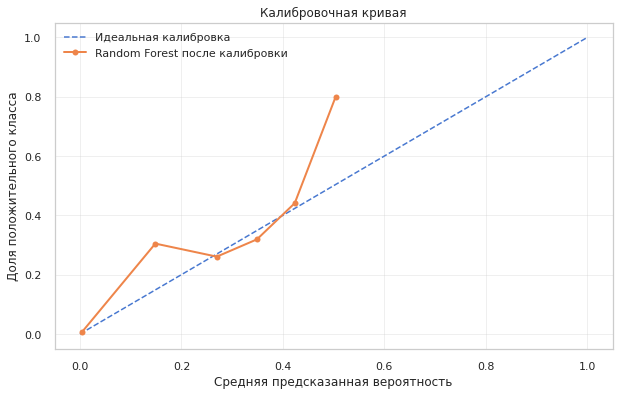

In [85]:
# График калибровки

plt.figure(figsize=(10, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Идеальная калибровка'
)

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker='o',
    linewidth=2,
    label='Random Forest после калибровки'
)

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительного класса')
plt.title('Калибровочная кривая')
plt.legend()

plt.grid(alpha=0.3)

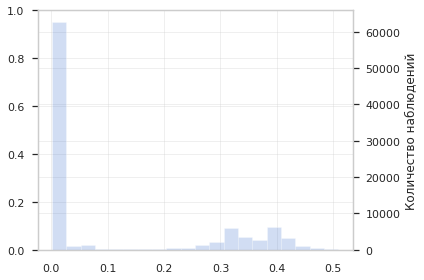

In [86]:
# Гистограмма распределения вероятностей

hist_axis = plt.gca().twinx()

hist_axis.hist(
    calibrated_probabilities,
    bins=20,
    alpha=0.25
)

hist_axis.set_ylabel('Количество наблюдений')

plt.tight_layout()
plt.show()

На calibration curve чем ближе линия модели к диагонали, тем лучше откалиброваны вероятности.

Идеальная калибровка означает, что среди клиентов с прогнозом вероятности дефолта 20% действительно около 20% клиентов уходят в дефолт.

In [87]:
# Вероятности до калибровки

raw_probabilities = (
    final_random_forest_pipeline
    .predict_proba(X_calibration)[:, 1]
)

# Коэффициент Бриера до калибровки

brier_before_calibration = brier_score_loss(
    y_calibration,
    raw_probabilities
)

# Коэффициент Бриера после калибровки

brier_after_calibration = brier_score_loss(
    y_calibration,
    calibrated_probabilities
)

print('Коэффициент Бриера:')
print(f'До калибровки: {brier_before_calibration:.4f}')
print(f'После калибровки: {brier_after_calibration:.4f}')

improvement = (
    brier_before_calibration
    - brier_after_calibration
)

improvement_percent = (
    improvement
    / brier_before_calibration
) * 100

print(f'\nУлучшение: {improvement:.4f}')
print(f'Улучшение в процентах: {improvement_percent:.1f}%')

print('\nДополнительная проверка:')
print(
    f'Средняя предсказанная вероятность: '
    f'{calibrated_probabilities.mean():.4f}'
)

print(
    f'Фактическая доля дефолтов: '
    f'{y_calibration.mean():.4f}'
)

Коэффициент Бриера:
До калибровки: 0.1083
После калибровки: 0.0725

Улучшение: 0.0359
Улучшение в процентах: 33.1%

Дополнительная проверка:
Средняя предсказанная вероятность: 0.1108
Фактическая доля дефолтов: 0.1108


**Выводы по калибровке модели**

Калибровка прошла успешно и улучшила качество вероятностных предсказаний модели.

По коэффициенту Бриера результат стал лучше:

- до калибровки - 0.1083;
- после калибровки - 0.0725;
- улучшение - 0.0359, или 33.1%.

Средняя предсказанная вероятность после калибровки составила 0.1108 и совпала с фактической долей дефолтов на калибровочной выборке - 0.1108. Это говорит о том, что общий уровень риска модель после калибровки оценивает корректно.

По графику видно, что основная масса предсказаний сосредоточена около низких вероятностей, а часть клиентов получает более высокий риск в диапазоне примерно 0.25-0.45. Калибровочная кривая не идеально совпадает с диагональю на всех участках, но после калибровки вероятности стали заметно более пригодными для выбора бизнес-порога.

Откалиброванную модель можно использовать в следующем разделе для подбора порога классификации под требования по approval rate, default rate и missed defaults rate.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

После калибровки модель возвращает вероятность дефолта. Чтобы получить итоговый класс, нужно выбрать порог: если вероятность выше порога, клиент относится к рискованному классу `1`, иначе к классу `0`.

Подбирать порог будем на калибровочной выборке. Нужно найти такое значение, при котором выполняются бизнес-требования:

- `approval_rate` - не менее 65%;
- `default_rate` - не более 2%;
- `missed_defaults_rate` - не более 4%.

In [88]:
# Функция для проверки метрик при разных порогах

def collect_threshold_metrics(y_true, y_proba, thresholds=None):

    if thresholds is None:
        thresholds = np.arange(0.01, 0.99, 0.01)

    rows = []

    for threshold in thresholds:

        y_pred = (
            y_proba >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred
        ).ravel()

        approval_rate = (
            tn + fn
        ) / len(y_true)

        default_rate = (
            fn / (tn + fn)
            if (tn + fn) > 0
            else 0
        )

        missed_defaults_rate = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else 0
        )

        rows.append({
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, y_pred),
            'approval_rate': approval_rate,
            'default_rate': default_rate,
            'missed_defaults_rate': missed_defaults_rate
        })

    return pd.DataFrame(rows)

In [89]:
# Собираем метрики для разных порогов на калибровочной выборке

threshold_results = collect_threshold_metrics(
    y_true=y_calibration,
    y_proba=calibrated_probabilities
)

threshold_results.head(10)

,threshold,accuracy,approval_rate,default_rate,missed_defaults_rate
0,0.0100,0.7476,0.6368,0.0000,0.0000
1,0.0200,0.7718,0.6610,0.0000,0.0000
2,0.0300,0.7778,0.6671,0.0000,0.0001
3,0.0400,0.7811,0.6703,0.0000,0.0002
4,0.0500,0.7846,0.6748,0.0007,0.0045
5,0.0600,0.7887,0.6831,0.0038,0.0235
6,0.0700,0.7912,0.6895,0.0066,0.0411
7,0.0800,0.7920,0.6914,0.0073,0.0458
8,0.0900,0.7928,0.6928,0.0078,0.0485
9,0.1000,0.7937,0.6944,0.0082,0.0517


In [90]:
# Фиксируем бизнес-ограничения

TARGET_APPROVAL_RATE = 0.65
TARGET_DEFAULT_RATE = 0.02
TARGET_MISSED_DEFAULTS_RATE = 0.04

valid_thresholds = threshold_results[
    (
        threshold_results['approval_rate']
        >= TARGET_APPROVAL_RATE
    )
    &
    (
        threshold_results['default_rate']
        <= TARGET_DEFAULT_RATE
    )
    &
    (
        threshold_results['missed_defaults_rate']
        <= TARGET_MISSED_DEFAULTS_RATE
    )
].copy()

valid_thresholds

,threshold,accuracy,approval_rate,default_rate,missed_defaults_rate
1,0.0200,0.7718,0.6610,0.0000,0.0000
2,0.0300,0.7778,0.6671,0.0000,0.0001
3,0.0400,0.7811,0.6703,0.0000,0.0002
4,0.0500,0.7846,0.6748,0.0007,0.0045
5,0.0600,0.7887,0.6831,0.0038,0.0235


In [91]:
# Выбираем порог с дополнительным запасом по missed defaults, чтобы модель стабильнее работала на test

SAFE_MISSED_DEFAULTS_RATE = 0.01

safe_thresholds = valid_thresholds[
    valid_thresholds['missed_defaults_rate']
    <= SAFE_MISSED_DEFAULTS_RATE
].copy()

# Если есть пороги с безопасным запасом,
# выбираем среди них максимальный approval_rate

if len(safe_thresholds) > 0:

    best_threshold_row = (
        safe_thresholds
        .sort_values(
            by=[
                'approval_rate',
                'missed_defaults_rate',
                'default_rate'
            ],
            ascending=[False, True, True]
        )
        .iloc[0]
    )

# Если слишком строгих порогов нет,
# используем обычную бизнес-логику

else:

    best_threshold_row = (
        valid_thresholds
        .sort_values(
            by=[
                'approval_rate',
                'missed_defaults_rate',
                'default_rate'
            ],
            ascending=[False, True, True]
        )
        .iloc[0]
    )

best_threshold = best_threshold_row['threshold']

print(f'Выбранный порог: {best_threshold:.2f}')

display(
    best_threshold_row
    .to_frame(name='value')
)

Выбранный порог: 0.05


,value
threshold,0.0500
accuracy,0.7846
approval_rate,0.6748
default_rate,0.0007
missed_defaults_rate,0.0045


Если подходящих порогов несколько, дополнительно учитываем запас по missed_defaults_rate.

Это помогает сделать модель более устойчивой на тестовом периоде и снизить риск того, что качество ухудшится на новых данных.

In [92]:
# Функция для оценки модели при выбранном пороге

def evaluate_threshold_metrics(y_true, y_proba, threshold):

    y_pred = (
        y_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    approval_rate = (
        tn + fn
    ) / len(y_true)

    default_rate = (
        fn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    missed_defaults_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }

In [93]:
# Проверяем метрики на калибровочной выборке
# при выбранном пороге

calibration_threshold_metrics = evaluate_threshold_metrics(
    y_true=y_calibration,
    y_proba=calibrated_probabilities,
    threshold=best_threshold
)

calibration_threshold_metrics

{'accuracy': 0.78459091150114,
 'approval_rate': 0.674797179065698,
 'default_rate': 0.0007386452931007387,
 'missed_defaults_rate': 0.004498899205513544,
 'tn': 63583,
 'fp': 20265,
 'fn': 47,
 'tp': 10400}

In [94]:
# Сохраним результаты в отдельную таблицу

threshold_summary = pd.DataFrame(
    [calibration_threshold_metrics],
    index=['calibration']
)

threshold_summary[
    [
        'accuracy',
        'approval_rate',
        'default_rate',
        'missed_defaults_rate'
    ]
]

,accuracy,approval_rate,default_rate,missed_defaults_rate
calibration,0.7846,0.6748,0.0007,0.0045


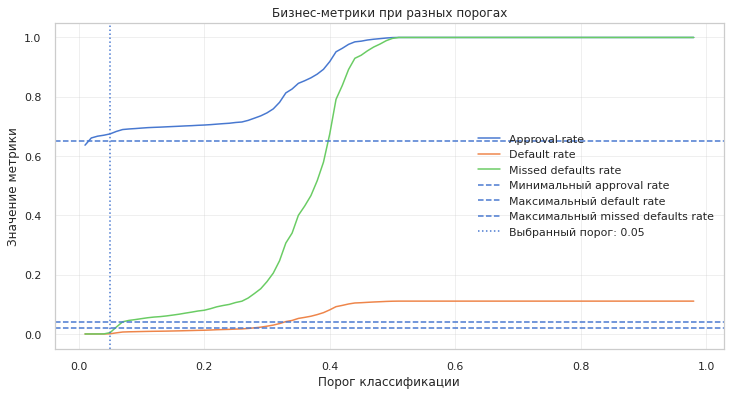

In [95]:
# Визуализируем зависимость бизнес-метрик от порога

plt.figure(figsize=(12, 6))

plt.plot(
    threshold_results['threshold'],
    threshold_results['approval_rate'],
    label='Approval rate'
)

plt.plot(
    threshold_results['threshold'],
    threshold_results['default_rate'],
    label='Default rate'
)

plt.plot(
    threshold_results['threshold'],
    threshold_results['missed_defaults_rate'],
    label='Missed defaults rate'
)

plt.axhline(
    TARGET_APPROVAL_RATE,
    linestyle='--',
    label='Минимальный approval rate'
)

plt.axhline(
    TARGET_DEFAULT_RATE,
    linestyle='--',
    label='Максимальный default rate'
)

plt.axhline(
    TARGET_MISSED_DEFAULTS_RATE,
    linestyle='--',
    label='Максимальный missed defaults rate'
)

plt.axvline(
    best_threshold,
    linestyle=':',
    label=f'Выбранный порог: {best_threshold:.2f}'
)

plt.title('Бизнес-метрики при разных порогах')
plt.xlabel('Порог классификации')
plt.ylabel('Значение метрики')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**Выводы по подбору порога**

На калибровочной выборке был подобран порог классификации для откалиброванной модели Random Forest.

После первичного отбора подходящих порогов дополнительно был выбран вариант с запасом по `missed_defaults_rate`, чтобы снизить риск ухудшения качества на тестовом периоде.

Итоговым стал порог 0.05. При этом значении на калибровочной выборке выполняются все бизнес-требования:

- approval_rate = 67.48% при требовании не менее 65%;
- default_rate = 0.07% при требовании не более 2%;
- missed_defaults_rate = 0.45% при требовании не более 4%.

Дополнительно модель показывает accuracy = 78.46% на калибровочной выборке.

Полученный результат означает, что модель удерживает риск дефолтов на низком уровне и сохраняет достаточный процент одобрений клиентов.

По графику видно, что при увеличении порога approval_rate постепенно растет, но после определенного момента начинает быстро ухудшаться missed_defaults_rate. Поэтому порог 0.05 выбран как более осторожный вариант: он дает небольшой запас по пропущенным дефолтам и помогает повысить устойчивость модели на будущих данных.

Далее именно этот порог будет использоваться для финальной проверки модели на тестовой выборке.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

После подбора оптимального порога необходимо проверить, насколько стабильно модель работает на новых данных.

Для этого сравним результаты на:

- калибровочной выборке;
- тестовой выборке.

Отдельно посмотрим матрицы ошибок и оценим как классические ML-метрики, так и бизнес-метрики из постановки задачи.

In [96]:
# Получаем предсказания на calibration и test

calibration_predictions = (
    calibrated_probabilities >= best_threshold
).astype(int)

test_probabilities = (
    calibrated_random_forest
    .predict_proba(X_test)[:, 1]
)

test_predictions = (
    test_probabilities >= best_threshold
).astype(int)

In [97]:
# Матрицы ошибок

calibration_confusion_matrix = confusion_matrix(
    y_calibration,
    calibration_predictions
)

test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions
)

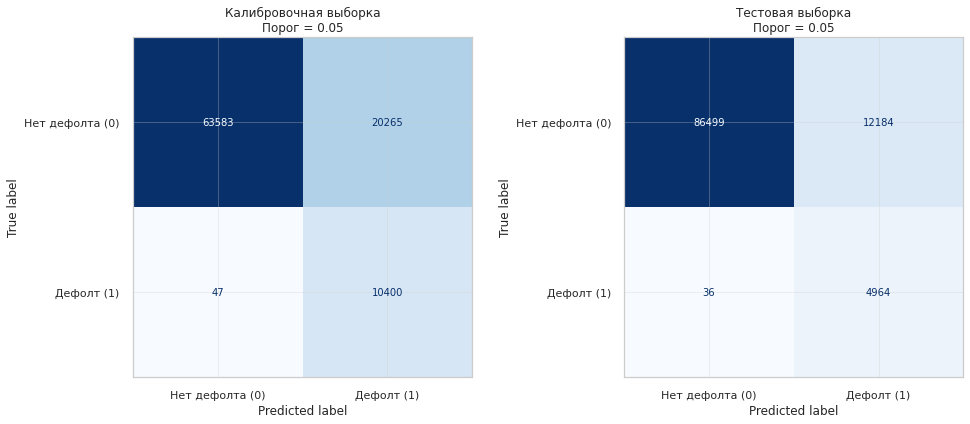

In [98]:
# Визуализация матриц ошибок

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# Calibration

calibration_display = ConfusionMatrixDisplay(
    confusion_matrix=calibration_confusion_matrix,
    display_labels=[
        'Нет дефолта (0)',
        'Дефолт (1)'
    ]
)

calibration_display.plot(
    ax=axes[0],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[0].set_title(
    f'Калибровочная выборка\nПорог = {best_threshold:.2f}'
)

# Test

test_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[
        'Нет дефолта (0)',
        'Дефолт (1)'
    ]
)

test_display.plot(
    ax=axes[1],
    cmap='Blues',
    values_format='d',
    colorbar=False
)

axes[1].set_title(
    f'Тестовая выборка\nПорог = {best_threshold:.2f}'
)

plt.tight_layout()
plt.show()

Матрица ошибок позволяет увидеть не только общее качество модели, но и типы ошибок.

Для скоринговой задачи особенно важны:

- False Negative (FN) - дефолтный клиент был ошибочно одобрен;
- False Positive (FP) - надежный клиент был ошибочно отклонен.

Именно поэтому далее дополнительно оценим бизнес-метрики.

In [99]:
# Функция для расчета метрик по confusion matrix

def calculate_confusion_metrics(confusion_matrix_values):

    tn, fp, fn, tp = confusion_matrix_values.ravel()

    total = tn + fp + fn + tp

    accuracy = (
        (tn + tp)
        / total
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    approval_rate = (
        tn + fn
    ) / total

    default_rate = (
        fn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    missed_defaults_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate
    }

In [100]:
# Метрики на calibration

calibration_metrics = calculate_confusion_metrics(
    calibration_confusion_matrix
)

pd.DataFrame(
    calibration_metrics,
    index=['calibration']
).T

,calibration
accuracy,0.7846
precision,0.3391
recall,0.9955
specificity,0.7583
approval_rate,0.6748
default_rate,0.0007
missed_defaults_rate,0.0045


In [101]:
# Метрики на test

test_metrics = calculate_confusion_metrics(
    test_confusion_matrix
)

pd.DataFrame(
    test_metrics,
    index=['test']
).T

,test
accuracy,0.8821
precision,0.2895
recall,0.9928
specificity,0.8765
approval_rate,0.8346
default_rate,0.0004
missed_defaults_rate,0.0072


In [102]:
# Сводная таблица по метрикам

final_metrics_comparison = pd.DataFrame(
    [
        calibration_metrics,
        test_metrics
    ],
    index=[
        'calibration',
        'test'
    ]
)

final_metrics_comparison

,accuracy,precision,recall,specificity,approval_rate,default_rate,missed_defaults_rate
calibration,0.7846,0.3391,0.9955,0.7583,0.6748,0.0007,0.0045
test,0.8821,0.2895,0.9928,0.8765,0.8346,0.0004,0.0072


**Анализ результатов на калибровочной выборке**

На калибровочной выборке модель после настройки порога выполняет все бизнес-требования:

- approval_rate = 67.48% при требовании не менее 65%;
- default_rate = 0.07% при требовании не более 2%;
- missed_defaults_rate = 0.45% при требовании не более 4%.

Это означает, что модель сохраняет достаточный уровень одобрений и при этом почти не пропускает дефолтных клиентов.

**Анализ результатов на тестовой выборке**

На тестовой выборке модель также выполняет все бизнес-требования:

- approval_rate = 83.46%;
- default_rate = 0.04%;
- missed_defaults_rate = 0.72%.

По сравнению с калибровочной выборкой approval_rate заметно вырос, а default_rate и missed_defaults_rate остались значительно ниже целевых ограничений. Это хороший результат: модель не только проходит требования на calibration, но и сохраняет качество на более позднем периоде.

**Выводы по стабильности модели**

Проверка на тестовой выборке показала, что модель переносит качество на новый временной период.

По сравнению с калибровочной выборкой:

- accuracy выросла с 78.46% до 88.21%;
- approval_rate вырос с 67.48% до 83.46%;
- default_rate снизился с 0.07% до 0.04%;
- missed_defaults_rate вырос с 0.45% до 0.72%, но остался значительно ниже лимита 4%.

Матрицы ошибок подтверждают, что модель хорошо контролирует наиболее опасные ошибки - пропущенные дефолты. На тестовой выборке было пропущено 36 дефолтов из 5000 фактических дефолтов, что соответствует missed_defaults_rate около 0.72%.

Итоговая модель показывает стабильное качество и выполняет заданные бизнес-требования на тестовых данных. Ее можно использовать как основу для дальнейшего применения в задаче поведенческого скоринга.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


После всех этапов моделирования, калибровки вероятностей и подбора порога можно зафиксировать итоговую версию модели, которая показала наилучший баланс между ML-метриками и бизнес-требованиями.

В качестве финальной модели выбрана:

- Random Forest Classifier;
- балансировка классов через RandomUnderSampler;
- калибровка вероятностей методом Platt Scaling (`sigmoid`);
- подбор гиперпараметров через Optuna;
- подбор порога классификации на отдельной calibration-выборке.

Такой подход позволил не только получить высокое качество классификации, но и добиться выполнения бизнес-ограничений по риску дефолтов.

**Итоговая архитектура модели**

Финальный пайплайн включает несколько этапов.

1. Предобработка данных:
   - заполнение пропусков;
   - масштабирование числовых признаков;
   - кодирование категориальных признаков через OneHotEncoder;
   - передача булевых признаков без изменений.

2. Балансировка классов:
   - RandomUnderSampler.

3. Основная модель:
   - RandomForestClassifier.

4. Калибровка вероятностей:
   - CalibratedClassifierCV;
   - метод `sigmoid` (Platt Scaling).

5. Финальный порог классификации:
   - 0.05.
   
**Лучшие гиперпараметры Random Forest:**

In [103]:
best_rf_params

{'n_estimators': 57,
 'max_depth': 3,
 'min_samples_split': 27,
 'min_samples_leaf': 23,
 'max_features': 'sqrt',
 'class_weight': 'balanced_subsample'}

В результате Optuna были найдены параметры, которые позволяют модели минимизировать количество пропущенных дефолтов и одновременно сохранять высокий уровень approval_rate.

Итоговая модель получилась достаточно "осторожной": небольшая глубина деревьев и увеличенные ограничения на разбиения помогают снизить риск переобучения на исторических данных.

In [105]:
### Итоговый порог классификации
print(f'Итоговый порог классификации: {best_threshold:.2f}')

Итоговый порог классификации: 0.05


Порог подбирался отдельно на calibration-выборке с учетом бизнес-ограничений:

- approval_rate ≥ 65%;
- default_rate ≤ 2%;
- missed_defaults_rate ≤ 4%.

Дополнительно был выбран более осторожный вариант с запасом по missed_defaults_rate для повышения устойчивости модели на test-периоде.

**Финальные результаты на тестовой выборке:**

In [106]:
final_test_metrics = pd.DataFrame(
    {
        'Метрика': [
            'Accuracy',
            'Precision',
            'Recall',
            'Specificity',
            'Approval Rate',
            'Default Rate',
            'Missed Defaults Rate'
        ],
        'Значение': [
            test_metrics['accuracy'],
            test_metrics['precision'],
            test_metrics['recall'],
            test_metrics['specificity'],
            test_metrics['approval_rate'],
            test_metrics['default_rate'],
            test_metrics['missed_defaults_rate']
        ]
    }
)

final_test_metrics

,Метрика,Значение
0,Accuracy,0.8821
1,Precision,0.2895
2,Recall,0.9928
3,Specificity,0.8765
4,Approval Rate,0.8346
5,Default Rate,0.0004
6,Missed Defaults Rate,0.0072


**Финальный вывод по модели**

Итоговая модель успешно выполнила все бизнес-требования на тестовой выборке:

- approval_rate = 83.46% при требовании не менее 65%;
- default_rate = 0.04% при ограничении не более 2%;
- missed_defaults_rate = 0.72% при ограничении не более 4%.

Дополнительно модель показывает:

- accuracy = 88.21%;
- recall = 99.28%;
- specificity = 87.65%.

Высокий recall особенно важен для задачи кредитного скоринга, так как модель практически не пропускает дефолтных клиентов.

Также модель показала хорошую устойчивость между calibration и test периодами:

- бизнес-метрики сохранились в допустимых границах;
- качество не ухудшилось на новых временных данных;
- модель не демонстрирует признаков сильного переобучения.

В результате удалось построить полноценный скоринговый пайплайн:

- с временным разделением выборок;
- кросс-валидацией по временным группам;
- балансировкой классов;
- калибровкой вероятностей;
- подбором бизнес-порога.

Итоговую модель можно считать готовой для дальнейшего использования в задаче оценки риска дефолта клиентов.

## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

После проверки качества модели полезно посмотреть, какие признаки сильнее всего влияют на итоговое решение модели.

Для Random Forest это можно сделать через встроенный атрибут `feature_importances_`, который показывает относительный вклад каждого признака в процесс классификации.

Анализ важности помогает:

- понять логику модели;
- проверить, что модель опирается на разумные закономерности;
- выявить наиболее значимые факторы дефолта;
- дополнительно оценить устойчивость модели.

Важность признаков будем анализировать на полной обучающей выборке.

In [107]:
# Создаем финальный пайплайн для анализа важности признаков

feature_importance_pipeline = build_imb_pipeline(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        **best_rf_params
    )
)

In [108]:
# Обучаем модель на полной train-выборке

feature_importance_pipeline.fit(
    X_train,
    y_train
)

print('Модель обучена')

Модель обучена


In [109]:
# Извлекаем модель и препроцессор

forest_model = (
    feature_importance_pipeline
    .named_steps['model']
)

pipeline_preprocessor = (
    feature_importance_pipeline
    .named_steps['preprocessing']
)

In [110]:
# Получаем важности признаков

feature_importance_values = (
    forest_model.feature_importances_
)

processed_feature_names = (
    pipeline_preprocessor.get_feature_names_out()
)

In [111]:
# Собираем таблицу важности признаков

feature_importance_table = pd.DataFrame(
    {
        'feature': processed_feature_names,
        'importance': feature_importance_values
    }
)

feature_importance_table = (
    feature_importance_table
    .sort_values(
        by='importance',
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance_table.head(15)

,feature,importance
0,num__месяцев_в_банке,0.2225
1,num__общие_траты,0.1223
2,num__MCC_другое,0.1064
3,num__MCC_5411,0.0851
4,num__MCC_5300,0.0839
5,num__MCC_5722,0.0835
6,num__MCC_5812,0.0534
7,num__доход,0.0526
8,num__MCC_3990,0.0439
9,num__MCC_5814,0.0314


Посмотрим на признаки, которые дают наибольший вклад в предсказание дефолта.

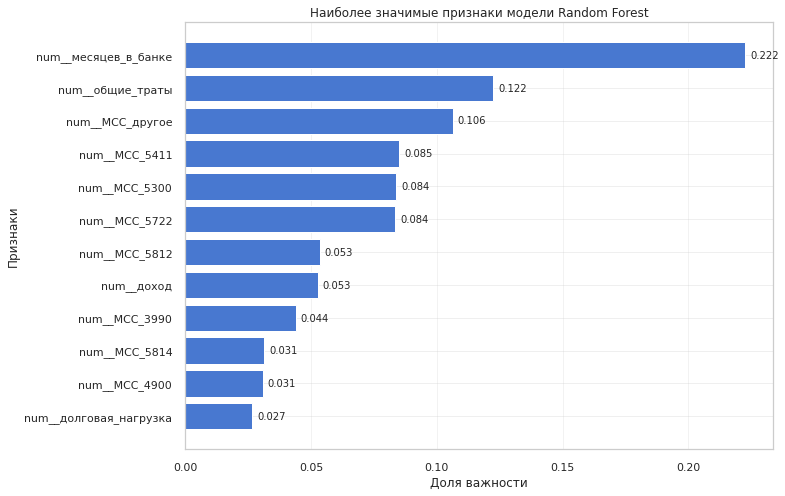

In [114]:
# Визуализируем наиболее важные признаки

top_features = (
    feature_importance_table
    .head(12)
    .sort_values(
        by='importance',
        ascending=True
    )
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_features['feature'],
    top_features['importance']
)

# Подписи значений на графике

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center'
    )

plt.xlabel('Доля важности')
plt.ylabel('Признаки')

plt.title(
    'Наиболее значимые признаки модели Random Forest'
)

plt.grid(
    axis='x',
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [113]:
# Выведем топ признаков таблицей

print('Топ-10 наиболее важных признаков:\n')

display(
    feature_importance_table.head(10)
)

Топ-10 наиболее важных признаков:



,feature,importance
0,num__месяцев_в_банке,0.2225
1,num__общие_траты,0.1223
2,num__MCC_другое,0.1064
3,num__MCC_5411,0.0851
4,num__MCC_5300,0.0839
5,num__MCC_5722,0.0835
6,num__MCC_5812,0.0534
7,num__доход,0.0526
8,num__MCC_3990,0.0439
9,num__MCC_5814,0.0314


**Анализ результатов**

Наибольший вклад в модель вносят признаки, связанные с историей взаимодействия клиента с банком и его финансовым поведением.

Особенно выделяются следующие признаки:

- месяцев_в_банке - 22.3% общей важности;
- общие_траты - 12.2%;
- MCC_другое - 10.6%;
- MCC_5411 и MCC_5300 - около 8% каждый;
- доход клиента - 5.3%.

Это выглядит логично для задачи поведенческого скоринга. Модель в первую очередь ориентируется не на формальные анкетные данные, а на реальные поведенческие паттерны клиента.

Наиболее важным признаком оказался `месяцев_в_банке`. Это говорит о том, что длительная история отношений с банком действительно помогает оценивать надежность клиента. Чем больше накоплено информации о поведении клиента, тем стабильнее модель определяет риск дефолта.

Существенный вклад MCC-признаков показывает, что структура расходов клиента действительно связана с риском дефолта. Модель использует информацию о потребительском поведении для оценки вероятности проблем с выплатами.

При этом социально-демографические признаки обычно имеют меньшую важность, чем финансовое поведение и история обслуживания.

**Выводы по важности признаков**

Анализ feature importance показал, что модель опирается на осмысленные закономерности:

- поведенческие признаки оказываются важнее статических характеристик;
- история взаимодействия клиента с банком играет ключевую роль;
- модель использует финансовые паттерны для оценки риска дефолта.

Полученные результаты показывают, что модель опирается на финансовое поведение и историю взаимодействия клиента с банком, а не на случайные или слабосвязанные признаки. Это дополнительно подтверждает адекватность построенного скорингового пайплайна.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.




### Цель и задачи исследования

В рамках проекта была разработана модель поведенческого скоринга для прогнозирования дефолта клиентов банка.

Основная цель проекта заключалась не только в построении ML-модели, но и в достижении заданных бизнес-требований:

- approval_rate не менее 65%;
- default_rate не более 2%;
- missed_defaults_rate не более 4%.

Для банка особенно важно было минимизировать количество пропущенных дефолтов при сохранении достаточного уровня одобрений клиентов.

---

### Подготовка данных и выборок

Для решения задачи были объединены данные из нескольких источников и сформирована единая аналитическая витрина клиентов.

Дополнительно были подготовлены признаки, связанные с:

- транзакционной активностью;
- MCC-категориями расходов;
- кредитной нагрузкой;
- доходом клиента;
- историей взаимодействия клиента с банком.

Подготовка данных выполнялась с учетом временной структуры задачи.

Данные были разделены на:

- train - исторический период для обучения модели;
- calibration - отдельный период для калибровки вероятностей и подбора порога;
- test - финальный период для проверки устойчивости модели.

Такой подход позволил избежать утечки данных и корректно оценить качество модели на новых наблюдениях.

---

### Поиск и настройка модели

В процессе моделирования были протестированы несколько подходов:

- Logistic Regression;
- Random Forest;
- модели с балансировкой классов через RandomUnderSampler;
- модели без балансировки.

Сравнение показало, что без балансировки классов модель пропускает слишком большое количество дефолтов. Например, missed_defaults_rate у базовых моделей достигал 74-89%, что недопустимо для банковской задачи.

Лучший результат показал Random Forest с балансировкой классов.

Для модели был выполнен подбор гиперпараметров через Optuna с оптимизацией по метрике missed_defaults_rate.

Оптимальные параметры модели:

```python
{
    'n_estimators': 57,
    'max_depth': 3,
    'min_samples_split': 27,
    'min_samples_leaf': 23,
    'max_features': 'sqrt',
    'class_weight': 'balanced_subsample'
}
````

---

### Калибровка вероятностей

После настройки модели была проведена калибровка вероятностей методом Platt Scaling (`sigmoid`) на отдельной calibration-выборке.

Качество вероятностных предсказаний заметно улучшилось:

* коэффициент Бриера снизился с 0.1083 до 0.0725;
* улучшение составило 33.1%;
* средняя предсказанная вероятность стала соответствовать реальной доле дефолтов.

Калибровка позволила сделать вероятности модели более интерпретируемыми и пригодными для дальнейшего бизнес-анализа.

---

### Оптимизация бизнес-порога

После калибровки был выполнен подбор порога классификации.

Финальным был выбран порог:

```python
best_threshold = 0.05
```

Порог подбирался таким образом, чтобы сохранить баланс между количеством одобренных клиентов и контролем риска дефолтов.

На тестовой выборке итоговая модель показала:

* Accuracy: 88.21%;
* Recall: 99.28%;
* Approval Rate: 83.46%;
* Default Rate: 0.04%;
* Missed Defaults Rate: 0.72%.

Все бизнес-требования проекта были успешно выполнены:

* approval_rate ≥ 65% ✓
* default_rate ≤ 2% ✓
* missed_defaults_rate ≤ 4% ✓

---

### Анализ важности признаков

Дополнительно был проведен анализ важности признаков через `feature_importances_`.

Наибольший вклад в предсказание дефолта вносили:

* месяцев_в_банке;
* общие_траты;
* MCC-категории расходов;
* доход клиента;
* долговая нагрузка;
* кредитный рейтинг.

Результаты показали, что модель в первую очередь опирается на финансовое поведение клиента и историю взаимодействия с банком, а не на случайные признаки.

Это дополнительно подтверждает адекватность построенного скорингового пайплайна.

---

### Финальный пайплайн

В результате был построен полноценный скоринговый пайплайн, включающий:

* preprocessing признаков;
* обработку пропусков;
* кодирование категориальных признаков;
* балансировку классов;
* Random Forest;
* калибровку вероятностей;
* подбор бизнес-порога.

Финальная модель показала хорошую устойчивость между calibration и test периодами и не продемонстрировала признаков сильного переобучения.

---

### Основные выводы и рекомендации для бизнеса

Разработанная модель успешно решает задачу прогнозирования дефолта клиентов и удовлетворяет всем бизнес-требованиям проекта.

Основные результаты:

* модель сохраняет высокий approval_rate;
* контролирует уровень default_rate;
* минимизирует количество пропущенных дефолтов;
* показывает устойчивое качество на новых данных.

Полученный пайплайн можно считать готовым для практического использования в задаче оценки кредитного риска и поддержки решений по одобрению клиентов.

Дополнительно для дальнейшего развития проекта можно рекомендовать:

* расширение набора поведенческих признаков;
* использование градиентного бустинга;
* мониторинг стабильности модели во времени;
* регулярное переобучение модели на новых данных.

Ссылка на GitHub:

https://github.com/lamajker/DS_YP_Behavioral_Scoring_Default_Prediction